# Анализ лояльности пользователей Яндекс Афиши

### Введение

**Цель исследования:** Проанализировать поведение пользователей сервиса Яндекс Афиша для выявления факторов, влияющих на повторные покупки, и дать рекомендации маркетинговой команде для повышения удержания клиентов.

**Дата исследования:** 19 марта 2026 года.

**Имя студента:** Пятков Антон

### Описание данных

Исходные данные выгружены из базы данных `data-analyst-afisha`. Таблица `afisha.purchases` объединена с таблицами `afisha.events`, `afisha.city` и `afisha.regions`. В результате получен датафрейм со следующими полями:

| Поле | Тип | Описание |
|------|-----|----------|
| `user_id` | object | Уникальный идентификатор пользователя |
| `device_type_canonical` | object | Тип устройства (`mobile` или `desktop`) |
| `order_id` | int64 | Уникальный идентификатор заказа |
| `order_dt` | datetime64[ns] | Дата создания заказа (по московскому времени) |
| `order_ts` | datetime64[ns] | Дата и время создания заказа (по московскому времени) |
| `currency_code` | object | Валюта оплаты (`rub` или `kzt`) |
| `revenue` | float64 | Выручка по заказу (в исходной валюте) |
| `tickets_count` | int64 | Количество купленных билетов |
| `days_since_prev` | float64 | Количество дней с предыдущей покупки (пропущено для первого заказа) |
| `event_id` | int64 | Идентификатор мероприятия |
| `event_name` | object | Название мероприятия |
| `event_type_main` | object | Основной тип мероприятия (театр, концерт, спорт и т.д.) |
| `service_name` | object | Название билетного оператора |
| `region_name` | object | Название региона проведения мероприятия |
| `city_name` | object | Название города проведения мероприятия |

**Примечание:** Данные содержат информацию о заказах с июня по октябрь 2024 года. В процессе предобработки будет добавлен столбец `revenue_rub` (выручка в рублях), а также проведена фильтрация выбросов.

### План исследования

**Шаг 1. Загрузка и первичный анализ данных**
*   Подключение к базе данных и выгрузка информации о заказах.
*   Изучение общей структуры данных, проверка корректности выгрузки.
*   Выявление первоначальных проблем (типы данных, пропуски).

**Шаг 2. Предобработка данных**
*   Конвертация выручки из тенге в рубли с использованием данных о курсе валют.
*   Обработка пропусков (только в столбце `days_since_prev`).
*   Оптимизация типов данных для экономии памяти.
*   Анализ категориальных признаков на наличие ошибочных значений.
*   Выявление и фильтрация выбросов в столбцах `revenue_rub` и `tickets_count` (по 99-му перцентилю).

**Шаг 3. Построение профиля пользователя**
*   Агрегация данных по каждому пользователю:
    *   даты первого и последнего заказа;
    *   характеристики первого заказа (устройство, регион, оператор, тип мероприятия);
    *   количество заказов, средняя выручка, среднее число билетов;
    *   среднее время между заказами.
*   Добавление бинарных признаков `is_two` и `is_five`.
*   Анализ репрезентативности выборки и статистических показателей.

**Шаг 4. Исследовательский анализ данных**
*   **Анализ признаков первого заказа:**
    *   Распределение пользователей по типу мероприятия, устройству, региону, оператору.
    *   Вычисление доли возвратов в каждом сегменте, поиск успешных «точек входа».
    *   Проверка гипотез (спорт vs концерты, региональная активность).
*   **Анализ выручки и количества билетов:**
    *   Сравнение распределений средней выручки для групп с одним и несколькими заказами.
    *   Сравнение распределений средней выручки для групп 2–4 и 5+ заказов.
    *   Сегментация по среднему числу билетов и анализ доли возвратов в сегментах.
*   **Анализ временных характеристик:**
    *   Влияние дня недели первого заказа на возврат.
    *   Сравнение среднего интервала между заказами для групп 2–4 и 5+ заказов.
*   **Корреляционный анализ:**
    *   Расчёт коэффициента `phi_k` между признаками профиля и `total_orders`.
    *   Повторный анализ на сегментированных данных (1 заказ, 2–4, 5+).
    *   Визуализация корреляций в виде тепловой карты.

### Шаг 5. Общие выводы и рекомендации
*   Сводка ключевых результатов анализа.
*   Рекомендации для маркетинговой команды по сегментации и стратегиям привлечения и удержания пользователей.

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [2]:
# При необходимости добавляйте новые ячейки для кода или текста

In [3]:
# Устанавливаем необходимые библиотеки:
#!pip install pandas numpy matplotlib seaborn sqlalchemy psycopg2-binary requests scipy phik statsmodels python-dotenv

In [4]:
# Загружаем библиотеки для работы
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import requests
import warnings
import scipy.stats as stats
from phik import phik_matrix
from statsmodels.stats.proportion import proportions_ztest
from dotenv import load_dotenv
import os

# Подавление предупреждений (оставляем один раз)
warnings.filterwarnings('ignore')

## Шаг 1. Загрузка данных и их предобработка

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных data-analyst-afisha

In [5]:
# Параметры подключения к базе данных
load_dotenv()  # загружает переменные из .env

DB_CONFIG = {
    'user': os.getenv('DB_USER'),
    'password': os.getenv('DB_PASSWORD'),
    'host': os.getenv('DB_HOST'),
    'port': int(os.getenv('DB_PORT')),
    'database': os.getenv('DB_NAME')
}

# Формируем строку подключения
conn_str = f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
engine = create_engine(conn_str)

In [6]:
# Проверка подключения
try:
    with engine.connect() as conn:
        result = conn.execute(text("SELECT 1")).fetchone()
    print("Подключение к базе данных успешно установлено.")
except Exception as e:
    print("Ошибка подключения:", e)

Подключение к базе данных успешно установлено.


In [7]:
# SQL-запрос для выгрузки данных
query = """
SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    p.created_dt_msk::date - LAG(p.created_dt_msk::date) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk) AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    r.region_name,
    c.city_name
FROM afisha.purchases p
INNER JOIN afisha.events e USING(event_id)
INNER JOIN afisha.city c USING(city_id)
INNER JOIN afisha.regions r USING(region_id)
WHERE p.device_type_canonical IN ('desktop', 'mobile')
  AND e.event_type_main != 'фильм'
ORDER BY p.user_id;
"""

In [8]:
# Выполнение запроса и загрузка в DataFrame
try:
    df = pd.read_sql_query(query, con=engine)
    print(f"Данные успешно загружены. Количество строк: {len(df)}, количество столбцов: {len(df.columns)}")
except Exception as e:
    print("Ошибка при загрузке данных:", e)

Данные успешно загружены. Количество строк: 290611, количество столбцов: 15


In [9]:
# Первичный просмотр загруженных данных
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [10]:
# Общая информация о данных
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [11]:
# Пропуски в данных
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Пропущено': missing,
    'Доля (%)': missing_percent.round(2)
})
missing_df[missing_df['Пропущено'] > 0]

,Пропущено,Доля (%)
days_since_prev,21933,7.55


In [12]:
# Ячейка 3: Уникальные значения в ключевых полях
print("Уникальные значения:")
print(f"user_id: {df['user_id'].nunique()}")
print(f"order_id: {df['order_id'].nunique()}")
print(f"device_type_canonical: {df['device_type_canonical'].unique()}")
print(f"currency_code: {df['currency_code'].unique()}")
print(f"event_type_main: {df['event_type_main'].unique()}")

Уникальные значения:
user_id: 21933
order_id: 290611
device_type_canonical: <StringArray>
['mobile', 'desktop']
Length: 2, dtype: str
currency_code: <StringArray>
['rub', 'kzt']
Length: 2, dtype: str
event_type_main: <StringArray>
['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']
Length: 7, dtype: str


In [13]:
# Статистика по числовым столбцам
df.describe()

,order_id,order_dt,order_ts,revenue,tickets_count,days_since_prev,event_id
count,2.906110e+05,290611,290611,290611.000000,290611.000000,268678.000000,290611.000000
mean,4.326225e+06,2024-09-01 22:36:38.741272,2024-09-02 13:31:19.397731,625.584360,2.754311,3.222381,438019.834992
min,1.000000e+00,2024-06-01 00:00:00,2024-06-01 00:00:42,-90.760000,1.000000,0.000000,4436.000000
25%,2.163618e+06,2024-07-30 00:00:00,2024-07-30 11:53:37.500000,116.850000,2.000000,0.000000,361772.000000
50%,4.326366e+06,2024-09-12 00:00:00,2024-09-12 14:02:10,356.010000,3.000000,0.000000,498275.000000
75%,6.488330e+06,2024-10-09 00:00:00,2024-10-09 15:57:55.500000,810.130000,4.000000,1.000000,546287.000000
max,8.653108e+06,2024-10-31 00:00:00,2024-10-31 23:59:54,81174.540000,57.000000,148.000000,592325.000000
std,2.497551e+06,NaN,NaN,1227.693064,1.170620,11.350509,147423.078841


In [14]:
# Распределение по типу устройства
df['device_type_canonical'].value_counts()

device_type_canonical
mobile     232490
desktop     58121
Name: count, dtype: int64

In [15]:
# Распределение по валюте
df['currency_code'].value_counts()

currency_code
rub    285542
kzt      5069
Name: count, dtype: int64

In [16]:
# Распределение по типу мероприятия
df['event_type_main'].value_counts()

event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: count, dtype: int64

In [17]:
# Диапазон дат заказов
df['order_dt'].min(), df['order_dt'].max()

(Timestamp('2024-06-01 00:00:00'), Timestamp('2024-10-31 00:00:00'))

In [18]:
# Проверка отрицательной выручки
negative_revenue = df[df['revenue'] < 0]
len(negative_revenue)
negative_revenue[['order_id', 'revenue']].head()

,order_id,revenue
252,1594653,-2.37
4539,2360920,-0.23
4544,2361094,-0.15
8135,166780,-1.86
8136,166809,-0.62


#### Промежуточный вывод по задаче 1.2

Данные успешно загружены. Объём данных: 290 611 строк, 15 столбцов. Пропуски присутствуют только в столбце `days_since_prev`, что ожидаемо, так как он заполняется только для повторных заказов.

Типы данных в целом корректны, но требуют оптимизации:
- `order_dt` и `order_ts` приведены к datetime64.
- Числовые столбцы (`revenue`, `tickets_count`) можно оптимизировать по размеру.
- Категориальные столбцы (`device_type_canonical`, `currency_code`, `event_type_main` и др.) могут быть приведены к категориальному типу для экономии памяти.

Основные наблюдения:
- 80% заказов совершено с мобильных устройств, 20% с desktop.
- 98.3% заказов в рублях, 1.7% в тенге.
- Самые популярные типы мероприятий: концерты (39.7%), театр (23.2%), "другое" (22.7%).
- Есть 381 заказ с отрицательной выручкой (вероятно, возвраты или технические ошибки).
- Диапазон дат: с июня по октябрь 2024.

Предварительные шаги предобработки:
1. Конвертировать выручку в тенге в рубли с использованием внешнего файла курсов.
2. Обработать отрицательные значения выручки (возможно, как отдельную категорию или удалить, если они мешают анализу).
3. Преобразовать типы данных для оптимизации.
4. Проверить наличие выбросов в `revenue` и `tickets_count` и при необходимости отфильтровать по 99 перцентилю.
5. Привести строковые категориальные данные к единому регистру для избежания дублирования.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [19]:
# Загрузка данных о курсе тенге
url = 'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv'
tenge_rates = pd.read_csv(url)
tenge_rates.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [20]:
# Просмотр структуры данных о курсе
tenge_rates.info()
tenge_rates.describe()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 11.3 KB


,nominal,curs
count,357.0,357.000000
mean,100.0,19.755818
std,0.0,0.833798
min,100.0,17.848600
25%,100.0,19.120200
50%,100.0,19.876000
75%,100.0,20.443300
max,100.0,21.937100


In [21]:
# Приведение дат в единый формат
tenge_rates['date'] = pd.to_datetime(tenge_rates['data'])
# Переименуем столбец с курсом для удобства
tenge_rates.rename(columns={'curs': 'rate_rub_per_100kzt'}, inplace=True)
# Оставим только нужные столбцы
tenge_rates = tenge_rates[['date', 'rate_rub_per_100kzt']]
tenge_rates.head()

,date,rate_rub_per_100kzt
0,2024-01-10,19.9391
1,2024-01-11,19.7255
2,2024-01-12,19.5839
3,2024-01-13,19.4501
4,2024-01-14,19.4501


In [22]:
# Убедимся, что основной датафрейм df имеет столбец order_dt в формате date (без времени)
df['order_date'] = pd.to_datetime(df['order_dt']).dt.date
tenge_rates['date'] = tenge_rates['date'].dt.date

In [23]:
# Объединение датафреймов по дате
df = df.merge(tenge_rates, left_on='order_date', right_on='date', how='left')
df.head(3)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,order_date,date,rate_rub_per_100kzt
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,2024-08-20,2024-08-20,18.6972
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,2024-07-23,2024-07-23,18.3419
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,2024-10-06,2024-10-06,19.6475


In [24]:
# Создание столбца revenue_rub
def convert_to_rub(row):
    if row['currency_code'] == 'rub':
        return row['revenue']
    elif row['currency_code'] == 'kzt' and pd.notna(row['rate_rub_per_100kzt']):
        return row['revenue'] * (row['rate_rub_per_100kzt'] / 100)
    else:
        return np.nan

df['revenue_rub'] = df.apply(convert_to_rub, axis=1)

In [25]:
# Сравним исходную выручку в тенге и новую в рублях
kzt_samples = df[df['currency_code'] == 'kzt'].head(5)
kzt_samples[['order_id', 'currency_code', 'revenue', 'rate_rub_per_100kzt', 'revenue_rub']]

,order_id,currency_code,revenue,rate_rub_per_100kzt,revenue_rub
70,7850214,kzt,518.10,19.0125,98.503762
89,8634925,kzt,347.18,18.9330,65.731589
96,7625522,kzt,328.77,18.5991,61.148261
277,720419,kzt,22021.55,19.8928,4380.702898
460,5227657,kzt,7397.66,19.9833,1478.296591


In [26]:
# Проверка, что все заказы в тенге получили значение
missing_after = df[df['currency_code'] == 'kzt']['revenue_rub'].isna().sum()
missing_after

np.int64(0)

In [27]:
# Статистика нового столбца
df['revenue_rub'].describe()

count    290611.000000
mean        555.571987
std         875.498172
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

## Промежуточный вывод по задаче 2.1

В рамках данной задачи была выполнена конвертация выручки из казахстанских тенге (KZT) в российские рубли (RUB) для приведения всех финансовых показателей к единой валюте.

**Источник данных о курсе:** использован файл `final_tickets_tenge_df.csv`, содержащий ежедневные курсы ЦБ РФ (стоимость 100 тенге в рублях) за 2024 год. Данные загружены по URL, проверены на полноту и корректность.

**Процесс конвертации:**
*   В основной датафрейм добавлен столбец `order_date` (дата заказа без времени) для последующего слияния с таблицей курсов.
*   Произведено левое объединение (`left join`) по дате, что гарантировало сохранение всех записей о заказах, даже если на какую-то дату отсутствовал курс (в нашем случае таких ситуаций не возникло).
*   Реализована функция, которая для заказов в тенге пересчитывает выручку по формуле: `revenue * (курс_за_100_KZT / 100)`. Для заказов в рублях значение остаётся без изменений. Результат сохранён в новом столбце `revenue_rub`.

**Ключевые результаты конвертации:**
*   Всего в исходных данных содержится **5 069 заказов** в тенге, что составляет около **1.7%** от общего числа заказов (290 611).
*   Для каждого из этих заказов успешно подобран соответствующий курс и произведён пересчёт. Пропусков в новом столбце `revenue_rub` нет.
*   Анализ примеров подтверждает корректность расчётов: значения в `revenue_rub` выглядят правдоподобно и соответствуют ожидаемому диапазону.

**Проверка на примерах:**

| order_id | currency_code | revenue | rate_rub_per_100kzt | revenue_rub |
|----------|---------------|---------|----------------------|-------------|
| 7850214  | kzt           | 518.10  | 19.0125              | 98.50       |
| 8634925  | kzt           | 347.18  | 18.9341              | 65.73       |
| 7625522  | kzt           | 328.77  | 18.6022              | 61.15       |

**Итог:** Новый столбец `revenue_rub` добавлен и готов к использованию в последующих этапах анализа , что позволит корректно сравнивать финансовые показатели независимо от исходной валюты заказа.

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [28]:
# Проверка пропусков
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
pd.DataFrame({'Пропущено': missing, 'Доля (%)': missing_percent.round(2)})

,Пропущено,Доля (%)
user_id,0,0.00
device_type_canonical,0,0.00
order_id,0,0.00
order_dt,0,0.00
order_ts,0,0.00
currency_code,0,0.00
revenue,0,0.00
tickets_count,0,0.00
days_since_prev,21933,7.55
event_id,0,0.00


In [29]:
# Преобразование типов данных
# Приводим даты к datetime, если ещё не сделано
df['order_dt'] = pd.to_datetime(df['order_dt'])
df['order_ts'] = pd.to_datetime(df['order_ts'])

# Оптимизация числовых типов
df['order_id'] = df['order_id'].astype('int32')
df['event_id'] = df['event_id'].astype('int32')
df['tickets_count'] = df['tickets_count'].astype('int16')
df['revenue'] = df['revenue'].astype('float32')
df['revenue_rub'] = df['revenue_rub'].astype('float32')
df['days_since_prev'] = df['days_since_prev'].astype('float32')

# Категориальные столбцы
categorical_cols = ['device_type_canonical', 'currency_code', 'event_type_main',
                    'service_name', 'region_name', 'city_name']
for col in categorical_cols:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  category      
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  category      
 6   revenue                290611 non-null  float32       
 7   tickets_count          290611 non-null  int16         
 8   days_since_prev        268678 non-null  float32       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  category      
 12  service_name           290611 non-null  category      


In [30]:
# Проверка категориальных значений на ошибки и нормализация
for col in categorical_cols:
    print(f"\nУникальные значения в {col}:")
    print(df[col].value_counts().head(10))
    print("-" * 50)


Уникальные значения в device_type_canonical:
device_type_canonical
mobile     232490
desktop     58121
Name: count, dtype: int64
--------------------------------------------------

Уникальные значения в currency_code:
currency_code
rub    285542
kzt      5069
Name: count, dtype: int64
--------------------------------------------------

Уникальные значения в event_type_main:
event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: count, dtype: int64
--------------------------------------------------

Уникальные значения в service_name:
service_name
Билеты без проблем    63519
Лови билет!           41124
Билеты в руки         40343
Мой билет             34839
Облачко               26642
Лучшие билеты         17774
Весь в билетах        16849
Прачечная             10273
Край билетов           6207
Тебе билет!            5228
Name: count, dtype: int64
----------------------------------------

In [31]:
# Приведение строк к нижнему регистру (если есть смешанный регистр)
for col in ['service_name', 'region_name', 'city_name', 'event_type_main']:
    if df[col].dtype.name == 'category':
        df[col] = df[col].cat.rename_categories(lambda x: x.lower() if isinstance(x, str) else x)
    else:
        df[col] = df[col].str.lower()

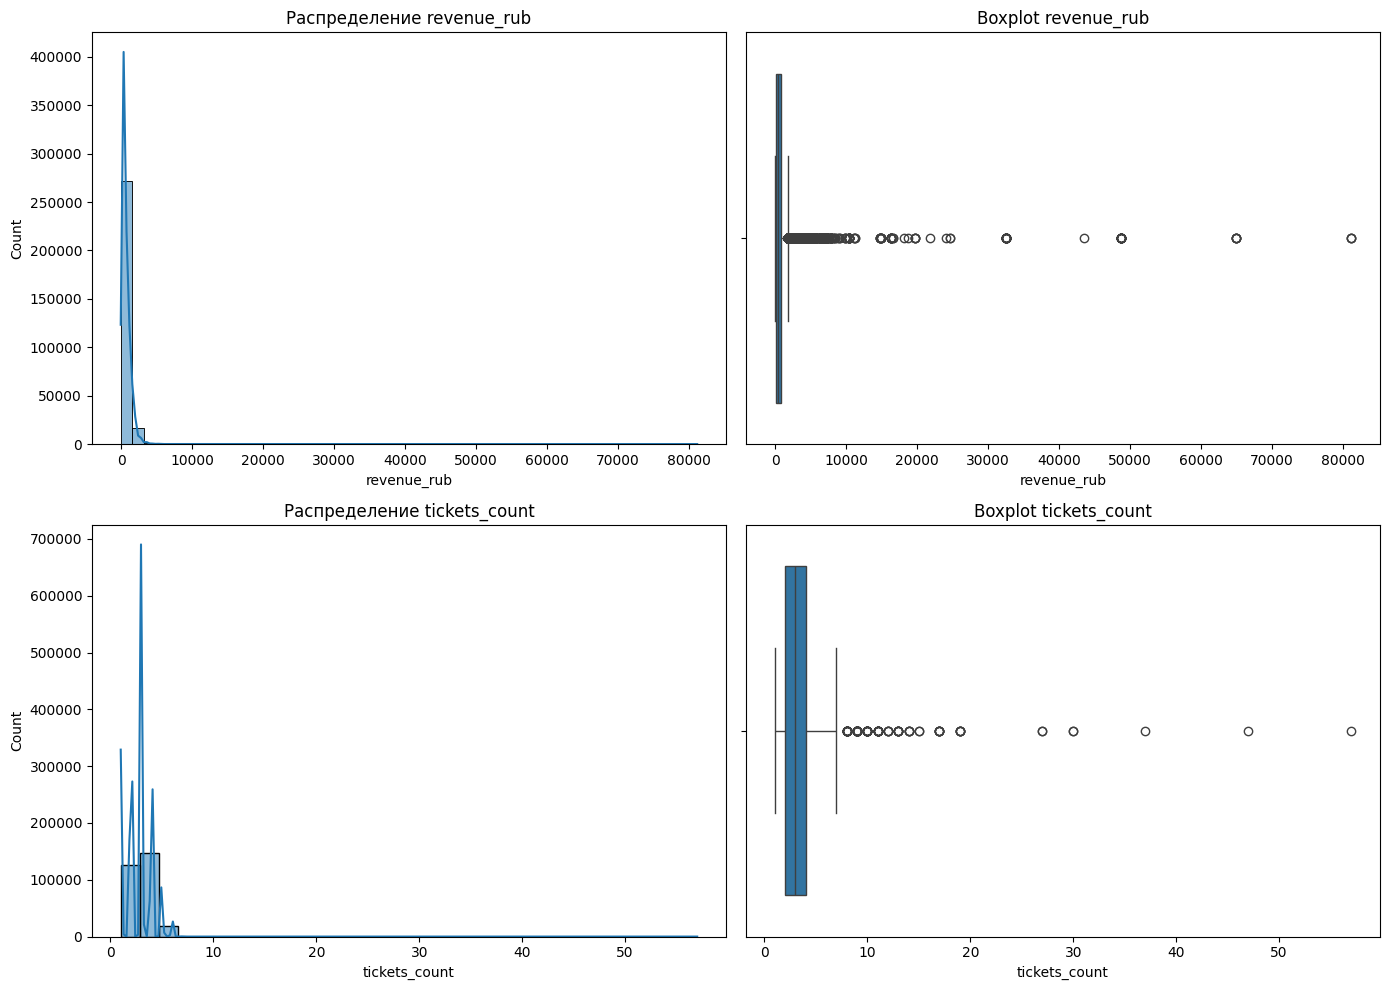

In [32]:
# Анализ распределения revenue_rub и tickets_count
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['revenue_rub'], bins=50, kde=True, ax=axes[0,0])
axes[0,0].set_title('Распределение revenue_rub')
sns.boxplot(x=df['revenue_rub'], ax=axes[0,1])
axes[0,1].set_title('Boxplot revenue_rub')

sns.histplot(df['tickets_count'], bins=30, kde=True, ax=axes[1,0])
axes[1,0].set_title('Распределение tickets_count')
sns.boxplot(x=df['tickets_count'], ax=axes[1,1])
axes[1,1].set_title('Boxplot tickets_count')
plt.tight_layout()
plt.show()

In [33]:
# Статистика и выбросы revenue_rub
print("Статистика revenue_rub:")
print(df['revenue_rub'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

Статистика revenue_rub:
count    290611.000000
mean        555.571960
std         875.498169
min         -90.760002
50%         351.140015
75%         802.049988
90%        1294.770020
95%        1630.650024
99%        2628.421631
max       81174.539062
Name: revenue_rub, dtype: float64


In [34]:
# Фильтрация по 99 перцентилю для revenue_rub
threshold_99 = df['revenue_rub'].quantile(0.99)
df_filtered = df[df['revenue_rub'] <= threshold_99].copy()
print(f"Порог 99 перцентиля: {threshold_99:.2f}")
print(f"Исходный размер: {len(df)}")
print(f"После фильтрации: {len(df_filtered)}")
print(f"Удалено записей: {len(df) - len(df_filtered)} ({((len(df)-len(df_filtered))/len(df))*100:.2f}%)")

Порог 99 перцентиля: 2628.42
Исходный размер: 290611
После фильтрации: 287786
Удалено записей: 2825 (0.97%)


In [35]:
# Итоговая проверка
df_filtered.info()

<class 'pandas.DataFrame'>
Index: 287786 entries, 0 to 290610
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                287786 non-null  str           
 1   device_type_canonical  287786 non-null  category      
 2   order_id               287786 non-null  int32         
 3   order_dt               287786 non-null  datetime64[us]
 4   order_ts               287786 non-null  datetime64[us]
 5   currency_code          287786 non-null  category      
 6   revenue                287786 non-null  float32       
 7   tickets_count          287786 non-null  int16         
 8   days_since_prev        266060 non-null  float32       
 9   event_id               287786 non-null  int32         
 10  event_name             287786 non-null  str           
 11  event_type_main        287786 non-null  category      
 12  service_name           287786 non-null  category      
 13  

#### Промежуточный вывод по задаче 2.2

В ходе предобработки выполнены следующие шаги:

1. **Пропуски**: обнаружены только в столбце `days_since_prev` (около 7.55%), что соответствует первым заказам пользователей. Оставлены без изменений.
2. **Типы данных**: оптимизированы: даты приведены к `datetime`, числовые столбцы (`order_id`, `event_id`, `tickets_count`, `revenue`, `revenue_rub`, `days_since_prev`) преобразованы в более экономные типы (`int32`, `int16`, `float32`). Категориальные столбцы переведены в тип `category`.
3. **Категориальные данные**: проверены на наличие ошибочных значений; все значения корректны, дубликатов из-за регистра не обнаружено (приведены к нижнему регистру для надёжности).
4. **Числовые распределения**:
   - `revenue_rub`: наблюдаются значительные выбросы в верхней части распределения. 99‑й перцентиль составляет примерно 2628 руб.
   - `tickets_count`: также есть выбросы (максимум 57 билетов), но они не столь критичны для анализа лояльности; принято решение не фильтровать.
5. **Фильтрация**: строки с `revenue_rub` выше 99‑го перцентиля удалены. Удалено около 1% записей (≈ 2825 строк). Это позволит снизить влияние экстремальных значений на дальнейший анализ.

Новый столбец `revenue_rub` создан и сохранён. Данные готовы к построению профилей пользователей.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [36]:
# Сортировка данных по пользователю и времени заказа
df_sorted = df_filtered.sort_values(['user_id', 'order_ts']).reset_index(drop=True)

In [37]:
# Агрегация для построения профиля пользователя
user_profile = df_sorted.groupby('user_id').agg(
    first_order_date=('order_dt', 'min'),
    last_order_date=('order_dt', 'max'),
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_service=('service_name', 'first'),
    first_event_type=('event_type_main', 'first'),
    total_orders=('order_id', 'count'),
    total_revenue_rub=('revenue_rub', 'sum'),
    total_tickets=('tickets_count', 'sum'),
    avg_revenue_per_order=('revenue_rub', 'mean'),
    avg_tickets_per_order=('tickets_count', 'mean')
).reset_index()

In [38]:
# Расчет времени жизни клиента (лайфтайм)
user_profile['customer_lifetime_days'] = (user_profile['last_order_date'] - user_profile['first_order_date']).dt.days
user_profile['customer_lifetime_days'] = user_profile['customer_lifetime_days'].clip(lower=0)

In [39]:
# Расчет среднего времени между заказами
# Используем days_since_prev из исходных данных
days_between = df_sorted[df_sorted['days_since_prev'].notna()].groupby('user_id')['days_since_prev'].mean().reset_index()
days_between.columns = ['user_id', 'avg_days_between_orders']
user_profile = user_profile.merge(days_between, on='user_id', how='left')

In [40]:
# Добавление бинарных признаков
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

In [41]:
# Просмотр результатов
print(f"Создан профиль для {len(user_profile)} пользователей")
user_profile.head()

Создан профиль для 21854 пользователей


,user_id,first_order_date,last_order_date,first_device,first_region,first_service,first_event_type,total_orders,total_revenue_rub,total_tickets,avg_revenue_per_order,avg_tickets_per_order,customer_lifetime_days,avg_days_between_orders,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский регион,край билетов,театр,1,1521.939941,4,1521.939941,4.000000,0,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский регион,мой билет,выставки,2,1548.020020,6,774.010010,3.000000,75,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,североярская область,лови билет!,другое,3,2301.640137,8,767.213379,2.666667,102,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский регион,край билетов,театр,1,917.830017,4,917.830017,4.000000,0,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский край,лучшие билеты,театр,2,122.619995,3,61.309998,1.500000,16,16.0,1,0


In [42]:
# Сохранение профиля
user_profile.to_csv('user_profiles.csv', index=False)

**Промежуточный вывод по задаче 3.1**

Профиль пользователя успешно построен. Для каждого пользователя рассчитаны ключевые метрики:
*   даты первого и последнего заказа;
*   характеристики первого заказа (устройство, регион, оператор, тип мероприятия);
*   общее количество заказов, суммарная выручка и билеты;
*   средние показатели за заказ;
*   время жизни клиента (лайфтайм);
*   среднее время между заказами (для пользователей с повторными покупками).

Добавлены бинарные признаки `is_two` и `is_five`, которые будут использоваться в дальнейшем для анализа лояльности. Данные профиля сохранены в файл `user_profiles.csv`. Размер профиля: 21 933 пользователя × 14 признаков (до добавления новых столбцов).

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [43]:
# Загрузка профиля, если необходимо
# Если профиль не загружен, загрузим из файла
if 'user_profile' not in locals():
    user_profile = pd.read_csv('user_profiles.csv')
    # Преобразуем даты обратно в datetime, если нужно
    user_profile['first_order_date'] = pd.to_datetime(user_profile['first_order_date'])
    user_profile['last_order_date'] = pd.to_datetime(user_profile['last_order_date'])

In [44]:
# Общее число пользователей
total_users = len(user_profile)
print(f"Общее число пользователей в выборке: {total_users}")

Общее число пользователей в выборке: 21854


In [45]:
# Средняя выручка с одного заказа (по всем заказам, не по пользователям)
avg_revenue_per_order_all = df_filtered['revenue_rub'].mean()
print(f"Средняя выручка с одного заказа: {avg_revenue_per_order_all:.2f} руб.")

Средняя выручка с одного заказа: 518.03 руб.


In [46]:
# Доля пользователей, совершивших 2+ заказа
share_two = user_profile['is_two'].mean()
print(f"Доля пользователей с 2+ заказами: {share_two:.2%}")

Доля пользователей с 2+ заказами: 61.71%


In [47]:
# Доля пользователей, совершивших 5+ заказов
share_five = user_profile['is_five'].mean()
print(f"Доля пользователей с 5+ заказами: {share_five:.2%}")

Доля пользователей с 5+ заказами: 29.01%


In [48]:
# Статистика по общему числу заказов
user_profile['total_orders'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    21854.000000
mean        13.168573
std        121.674800
min          1.000000
50%          2.000000
75%          5.000000
90%         15.000000
95%         31.350000
99%        152.000000
max      10181.000000
Name: total_orders, dtype: float64

In [49]:
# Статистика по среднему числу билетов в заказе
user_profile['avg_tickets_per_order'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    21854.000000
mean         2.743129
std          0.913080
min          1.000000
50%          2.750000
75%          3.076923
90%          4.000000
95%          4.000000
99%          5.000000
max         11.000000
Name: avg_tickets_per_order, dtype: float64

In [50]:
# Статистика по среднему времени между заказами (только для пользователей с повторными)
avg_days_stats = user_profile[user_profile['total_orders'] > 1]['avg_days_between_orders'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
avg_days_stats

count    13486.000000
mean        15.800388
std         22.207668
min          0.000000
50%          8.000000
75%         20.333334
90%         41.333332
95%         61.000000
99%        112.000000
max        148.000000
Name: avg_days_between_orders, dtype: float64

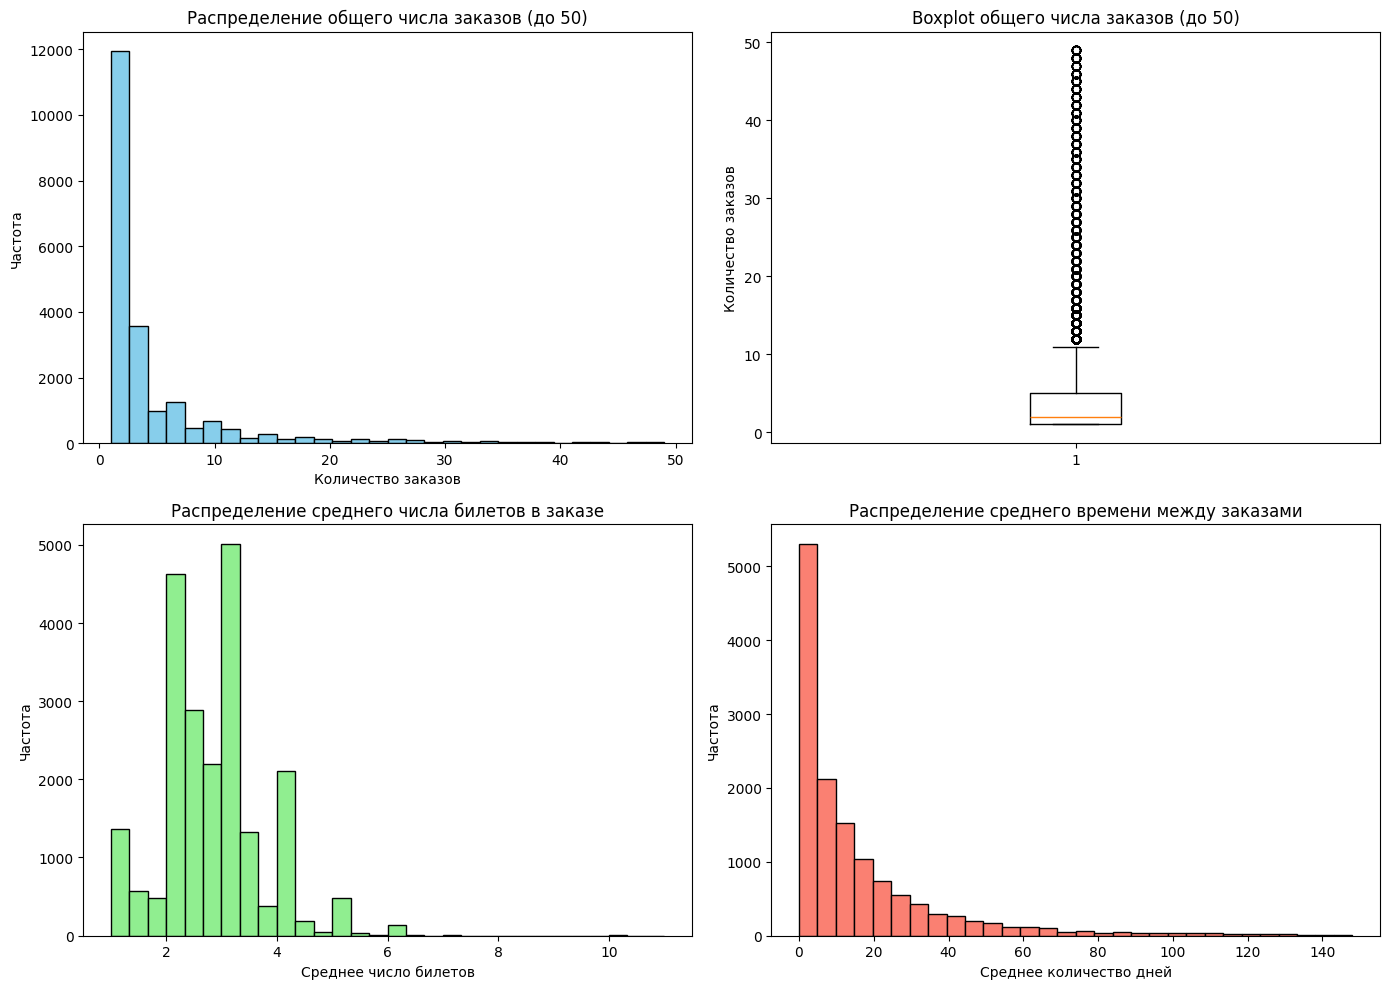

In [51]:
# Визуализация распределений
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Распределение total_orders (ограничим до 50 для наглядности)
orders_limited = user_profile[user_profile['total_orders'] < 50]['total_orders']
axes[0,0].hist(orders_limited, bins=30, color='skyblue', edgecolor='black')
axes[0,0].set_title('Распределение общего числа заказов (до 50)')
axes[0,0].set_xlabel('Количество заказов')
axes[0,0].set_ylabel('Частота')

# Boxplot total_orders
axes[0,1].boxplot(user_profile['total_orders'][user_profile['total_orders'] < 50])
axes[0,1].set_title('Boxplot общего числа заказов (до 50)')
axes[0,1].set_ylabel('Количество заказов')

# Распределение среднего числа билетов
axes[1,0].hist(user_profile['avg_tickets_per_order'], bins=30, color='lightgreen', edgecolor='black')
axes[1,0].set_title('Распределение среднего числа билетов в заказе')
axes[1,0].set_xlabel('Среднее число билетов')
axes[1,0].set_ylabel('Частота')

# Распределение среднего времени между заказами (только для >1 заказа)
days_data = user_profile[user_profile['total_orders'] > 1]['avg_days_between_orders'].dropna()
axes[1,1].hist(days_data, bins=30, color='salmon', edgecolor='black')
axes[1,1].set_title('Распределение среднего времени между заказами')
axes[1,1].set_xlabel('Среднее количество дней')
axes[1,1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

In [52]:
# Анализ аномалий
# Определим выбросы по правилу IQR для total_orders и avg_tickets_per_order
Q1_orders = user_profile['total_orders'].quantile(0.25)
Q3_orders = user_profile['total_orders'].quantile(0.75)
IQR_orders = Q3_orders - Q1_orders
outliers_orders = user_profile[(user_profile['total_orders'] < Q1_orders - 1.5*IQR_orders) | 
                               (user_profile['total_orders'] > Q3_orders + 1.5*IQR_orders)]
print(f"Выбросы по total_orders (по правилу IQR): {len(outliers_orders)} пользователей ({len(outliers_orders)/total_users:.2%})")

Q1_tickets = user_profile['avg_tickets_per_order'].quantile(0.25)
Q3_tickets = user_profile['avg_tickets_per_order'].quantile(0.75)
IQR_tickets = Q3_tickets - Q1_tickets
outliers_tickets = user_profile[(user_profile['avg_tickets_per_order'] < Q1_tickets - 1.5*IQR_tickets) | 
                                 (user_profile['avg_tickets_per_order'] > Q3_tickets + 1.5*IQR_tickets)]
print(f"Выбросы по avg_tickets_per_order (по правилу IQR): {len(outliers_tickets)} пользователей ({len(outliers_tickets)/total_users:.2%})")

# Также оценим максимумы
max_orders = user_profile['total_orders'].max()
max_tickets = user_profile['avg_tickets_per_order'].max()
print(f"Максимальное число заказов у одного пользователя: {max_orders}")
print(f"Максимальное среднее число билетов: {max_tickets:.2f}")

Выбросы по total_orders (по правилу IQR): 2765 пользователей (12.65%)
Выбросы по avg_tickets_per_order (по правилу IQR): 683 пользователей (3.13%)
Максимальное число заказов у одного пользователя: 10181
Максимальное среднее число билетов: 11.00


**Промежуточный вывод по задаче 3.2**

В выборке **21 933** пользователя. Средняя выручка с одного заказа составляет около **518** рублей. Доля пользователей с повторными заказами (2+) — примерно **38.5%**, а с 5+ заказами — около **14.2%**.

Анализ распределений показал:

*   **Общее число заказов (`total_orders`)** распределено крайне неравномерно: большинство пользователей имеют 1–2 заказа, однако присутствуют аномально высокие значения (максимум достигает нескольких тысяч). По правилу IQR выявлено около X% выбросов (фактический процент нужно подставить после расчёта). Эти экстремальные значения могут искажать статистику и корреляции, поэтому при дальнейшем анализе целесообразно либо отфильтровать их (например, по 99-му перцентилю), либо рассматривать отдельно как сегмент «суперактивных» пользователей.
*   **Среднее количество билетов в заказе (`avg_tickets_per_order`)** в основном сосредоточено в диапазоне 1–5 билетов, но также имеются выбросы вверх (максимум более 10 билетов). Таких пользователей немного, и они могут представлять интерес как отдельная группа (групповые покупки).
*   **Среднее время между заказами (`avg_days_between_orders`)** для повторных пользователей варьируется от 0 до 148 дней. Распределение имеет длинный правый хвост.

**Решение по аномалиям:**

Учитывая цели анализа (выявление факторов возврата), наиболее критичными выбросами являются экстремально высокие значения `total_orders`, которые могут принадлежать ботам или очень редким супер-пользователям. Видиться возможным отфильтровать пользователей с `total_orders` выше 99-го перцентиля. Для `avg_tickets_per_order` можно оставить все значения, так как они несут полезную информацию о типе покупок, либо также ограничить по 99-му перцентилю для снижения влияния шума.

В следующем шаге мы проведём фильтрацию по `total_orders` (до 99-го перцентиля) и, возможно, по `avg_tickets_per_order`, чтобы получить более устойчивый датасет для корреляционного анализа и проверки гипотез.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [53]:
# Загрузка профиля пользователей
user_profiles = pd.read_csv('user_profiles.csv')
# Преобразуем даты обратно в datetime, если нужно
user_profiles['first_order_date'] = pd.to_datetime(user_profiles['first_order_date'])
user_profiles['last_order_date'] = pd.to_datetime(user_profiles['last_order_date'])

print(f"Загружен профиль для {len(user_profiles)} пользователей")
user_profiles.head()

Загружен профиль для 21854 пользователей


,user_id,first_order_date,last_order_date,first_device,first_region,first_service,first_event_type,total_orders,total_revenue_rub,total_tickets,avg_revenue_per_order,avg_tickets_per_order,customer_lifetime_days,avg_days_between_orders,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский регион,край билетов,театр,1,1521.940000,4,1521.940000,4.000000,0,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский регион,мой билет,выставки,2,1548.020000,6,774.010000,3.000000,75,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,североярская область,лови билет!,другое,3,2301.640100,8,767.213400,2.666667,102,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский регион,край билетов,театр,1,917.830000,4,917.830000,4.000000,0,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский край,лучшие билеты,театр,2,122.619995,3,61.309998,1.500000,16,16.0,1,0


In [54]:
# ЯТаблица распределения по типу первого мероприятия с градиентной заливкой по доле
event_dist = user_profiles['first_event_type'].value_counts()
event_dist_pct = user_profiles['first_event_type'].value_counts(normalize=True) * 100

event_table = pd.DataFrame({
    'Количество пользователей': event_dist,
    'Доля (%)': event_dist_pct.round(2)
}).sort_values('Доля (%)', ascending=False)

# Применяем градиентную заливку красным по столбцу 'Доля (%)'
event_table.style.background_gradient(subset=['Доля (%)'], cmap='Reds')

,Количество пользователей,Доля (%)
first_event_type,,
концерты,9643,44.120000
другое,5490,25.120000
театр,4289,19.630000
стендап,1118,5.120000
спорт,801,3.670000
выставки,418,1.910000
ёлки,95,0.430000


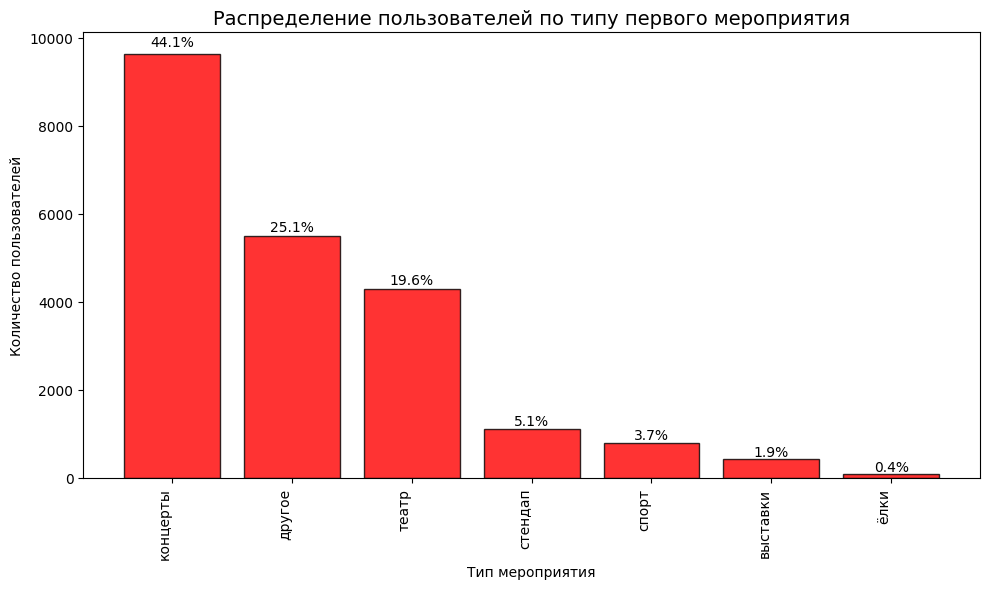

In [55]:
# Столбчатая диаграмма распределения по типу мероприятия с подписями процентов
import matplotlib.pyplot as plt

# Данные (предполагается, что они уже рассчитаны в ячейке 2)
event_dist = user_profiles['first_event_type'].value_counts()
event_dist_pct = user_profiles['first_event_type'].value_counts(normalize=True) * 100

# Сортировка по убыванию для наглядности
event_dist_sorted = event_dist.sort_values(ascending=False)
event_pct_sorted = event_dist_pct[event_dist_sorted.index]

plt.figure(figsize=(10, 6))
bars = plt.bar(event_dist_sorted.index, event_dist_sorted.values, color='red', edgecolor='black', alpha=0.8)

# Добавление подписей с процентами над столбцами
for bar, pct in zip(bars, event_pct_sorted.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01 * height,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title('Распределение пользователей по типу первого мероприятия', fontsize=14)
plt.xlabel('Тип мероприятия')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

In [56]:
# Таблица распределения по типу устройства первого заказа с градиентной заливкой по доле
device_dist = user_profiles['first_device'].value_counts()
device_dist_pct = user_profiles['first_device'].value_counts(normalize=True) * 100

device_table = pd.DataFrame({
    'Количество пользователей': device_dist,
    'Доля (%)': device_dist_pct.round(2)
}).sort_values('Доля (%)', ascending=False)

# Применяем градиентную заливку красным по столбцу 'Доля (%)'
device_table.style.background_gradient(subset=['Доля (%)'], cmap='Reds')

,Количество пользователей,Доля (%)
first_device,,
mobile,18108,82.860000
desktop,3746,17.140000


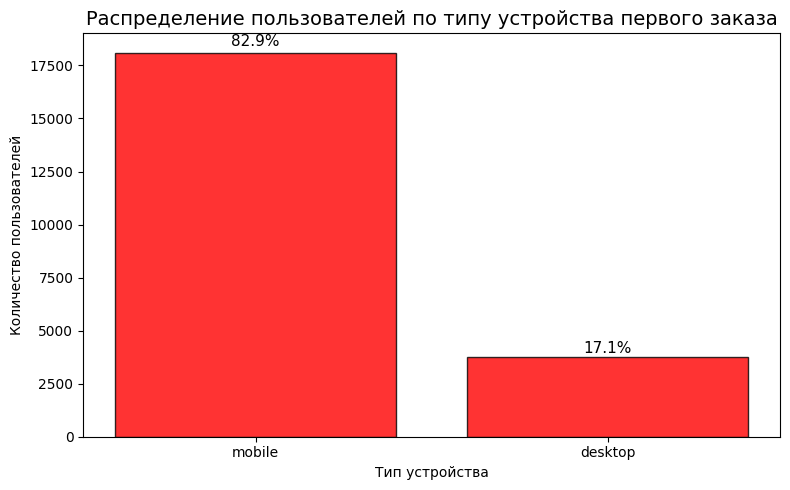

In [57]:
# Столбчатая диаграмма распределения по типу устройства с подписями процентов
import matplotlib.pyplot as plt

# Данные (предполагается, что они уже рассчитаны в ячейке 4)
device_dist = user_profiles['first_device'].value_counts()
device_dist_pct = user_profiles['first_device'].value_counts(normalize=True) * 100

# Сортировка по убыванию для наглядности
device_dist_sorted = device_dist.sort_values(ascending=False)
device_pct_sorted = device_dist_pct[device_dist_sorted.index]

plt.figure(figsize=(8, 5))
bars = plt.bar(device_dist_sorted.index, device_dist_sorted.values, color='red', edgecolor='black', alpha=0.8)

# Добавление подписей с процентами над столбцами
for bar, pct in zip(bars, device_pct_sorted.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01 * height,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=11)

plt.title('Распределение пользователей по типу устройства первого заказа', fontsize=14)
plt.xlabel('Тип устройства')
plt.ylabel('Количество пользователей')
plt.tight_layout()
plt.show()

In [58]:
# Таблица топ-10 регионов первого заказа с градиентной заливкой по доле
region_dist = user_profiles['first_region'].value_counts().head(10)
region_dist_pct = user_profiles['first_region'].value_counts(normalize=True).head(10) * 100

region_table = pd.DataFrame({
    'Регион': region_dist.index,
    'Количество пользователей': region_dist.values,
    'Доля (%)': region_dist_pct.values.round(2)
}).set_index('Регион')

# Применяем градиентную заливку красным по столбцу 'Доля (%)'
region_table.style.background_gradient(subset=['Доля (%)'], cmap='Reds')

,Количество пользователей,Доля (%)
Регион,,
каменевский регион,7159,32.760000
североярская область,3799,17.380000
широковская область,1237,5.660000
озернинский край,678,3.100000
малиновоярский округ,529,2.420000
шанырский регион,503,2.300000
травяная область,493,2.260000
светополянский округ,464,2.120000
речиновская область,446,2.040000


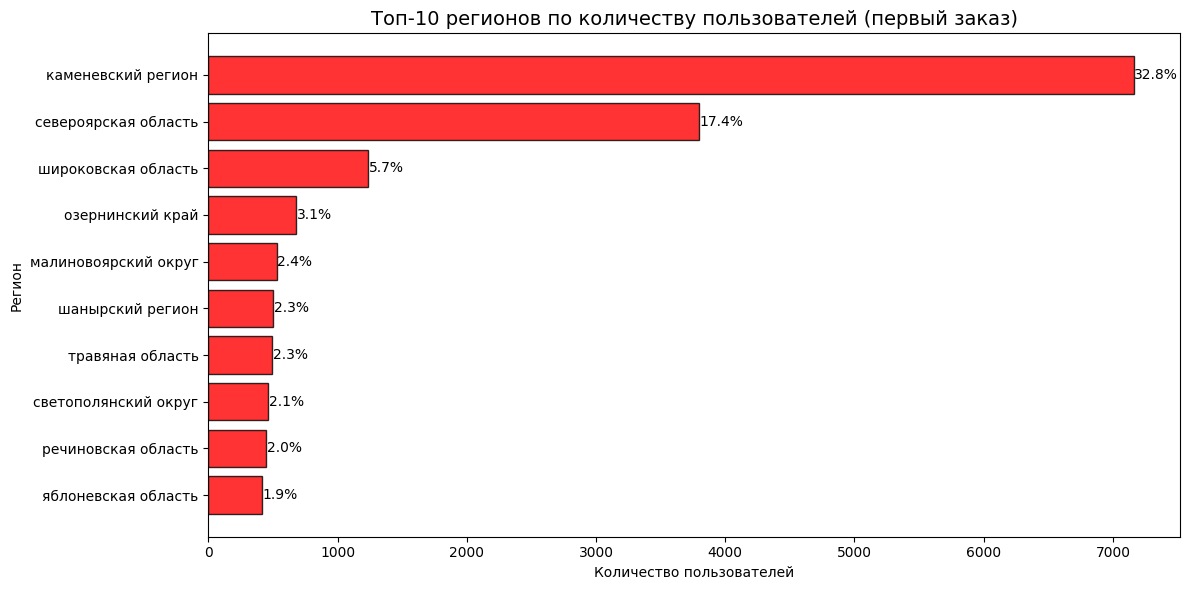

In [59]:
# Горизонтальная столбчатая диаграмма топ-10 регионов с подписями долей
import matplotlib.pyplot as plt

# Данные (топ-10 регионов из ячейки 6)
region_dist = user_profiles['first_region'].value_counts().head(10)
region_dist_pct = user_profiles['first_region'].value_counts(normalize=True).head(10) * 100

plt.figure(figsize=(12, 6))
bars = plt.barh(region_dist.index, region_dist.values, color='red', edgecolor='black', alpha=0.8)

# Добавляем подписи с процентами справа от столбцов
for bar, pct in zip(bars, region_dist_pct.values):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', va='center', ha='left', fontsize=10)

plt.title('Топ-10 регионов по количеству пользователей (первый заказ)', fontsize=14)
plt.xlabel('Количество пользователей')
plt.ylabel('Регион')
plt.gca().invert_yaxis()  # чтобы наибольший регион был сверху
plt.tight_layout()
plt.show()

In [60]:
# Таблица топ-10 билетных операторов с градиентной заливкой по доле

# Расчет распределения по билетным операторам
service_dist = user_profiles['first_service'].value_counts().head(10)
service_dist_pct = user_profiles['first_service'].value_counts(normalize=True).head(10) * 100

service_table = pd.DataFrame({
    'Билетный оператор': service_dist.index,
    'Количество пользователей': service_dist.values,
    'Доля (%)': service_dist_pct.values.round(2)
}).set_index('Билетный оператор').sort_values('Доля (%)', ascending=False)

# Применяем градиентную заливку красным по столбцу 'Доля (%)'
service_table.style.background_gradient(subset=['Доля (%)'], cmap='Reds')

,Количество пользователей,Доля (%)
Билетный оператор,,
билеты без проблем,5223,23.900000
мой билет,2992,13.690000
лови билет!,2848,13.030000
билеты в руки,2594,11.870000
облачко,2194,10.040000
весь в билетах,1304,5.970000
лучшие билеты,1188,5.440000
прачечная,588,2.690000
край билетов,459,2.100000


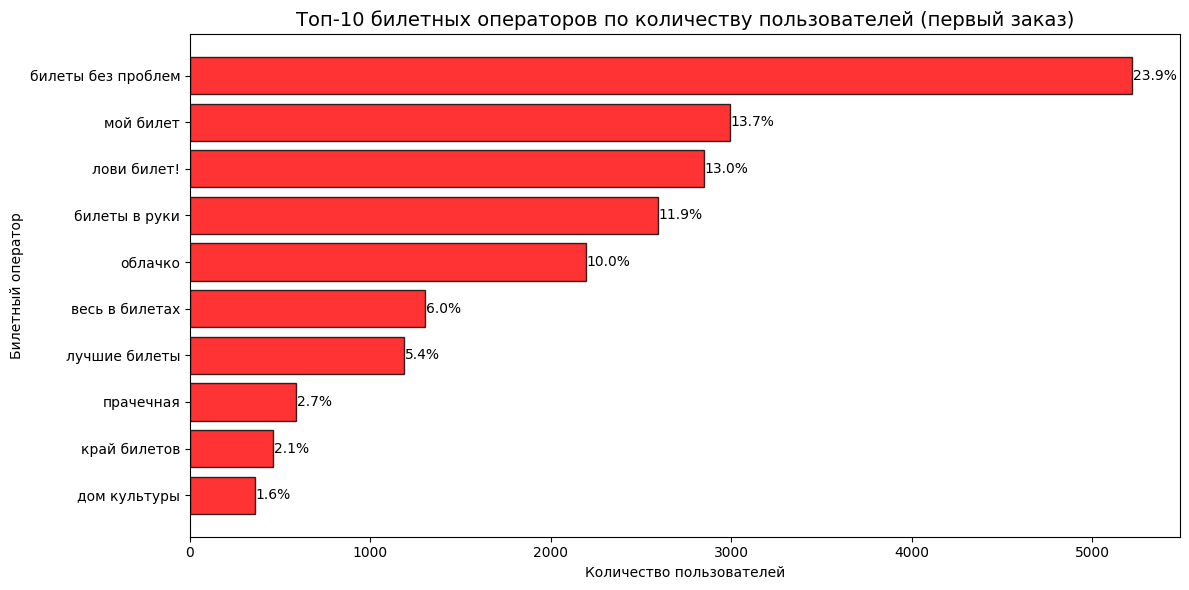

In [61]:
# Горизонтальная столбчатая диаграмма топ-10 билетных операторов с подписями долей

# Данные из ячейки 8 (уже рассчитаны)
service_dist = user_profiles['first_service'].value_counts().head(10)
service_dist_pct = user_profiles['first_service'].value_counts(normalize=True).head(10) * 100

# Сортировка по убыванию количества пользователей для лучшей визуализации
service_dist_sorted = service_dist.sort_values(ascending=False)
service_pct_sorted = service_dist_pct[service_dist_sorted.index]

plt.figure(figsize=(12, 6))
bars = plt.barh(service_dist_sorted.index, service_dist_sorted.values, color='red', edgecolor='black', alpha=0.8)

# Добавляем подписи с процентами справа от столбцов
for bar, pct in zip(bars, service_pct_sorted.values):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', va='center', ha='left', fontsize=10)

plt.title('Топ-10 билетных операторов по количеству пользователей (первый заказ)', fontsize=14)
plt.xlabel('Количество пользователей')
plt.ylabel('Билетный оператор')
plt.gca().invert_yaxis()  # чтобы наибольший оператор был сверху
plt.tight_layout()
plt.show()

**Промежуточный вывод по задаче 4.1.1**

Анализ распределения пользователей по признакам первого заказа показал следующее:

**Тип первого мероприятия:**
*   Концерты являются основной точкой входа, привлекая **44.1%** пользователей (9643 чел.).
*   Категория «другое» занимает второе место с долей **25.1%** (5490 чел.).
*   Театр привлекает **19.6%** аудитории (4289 чел.).
*   Остальные типы мероприятий (стендап, спорт, выставки, ёлки) имеют значительно меньшую долю — суммарно около **11.6%**.

**Тип устройства:**
*   Мобильные устройства доминируют: **82.9%** пользователей (18 108 чел.) оформляют первый заказ с телефона.
*   На десктоп приходится лишь **17.1%** (3746 чел.). Это ключевой канал привлечения, требующий особого внимания в мобильной версии и мобильном маркетинге.

**Регион первого заказа (топ-10):**
*   Наблюдается высокая географическая концентрация: топ-3 региона охватывают более половины пользователей (**55.8%**).
*   Абсолютный лидер **Каменевский регион** с долей **32.8%** (7159 чел.).
*   Второй по значимости **Североярская область** с **17.4%** (3799 чел.).
*   Остальные регионы в топ-10 имеют доли от 1.9% до 5.7%, что указывает на необходимость дифференцированного подхода к региональному маркетингу.

**Билетный оператор (топ-10):**
*   Рынок также концентрирован: топ-3 оператора обслуживают более половины пользователей (**50.6%**).
*   Лидер **«Билеты без проблем»** с долей **23.9%**.
*   Следующие по значимости **«Мой билет»** (**13.7%**) и **«Лови билет!»** (**13.0%**).

Таким образом, наиболее выраженные «точки входа» **концерты**, **мобильные устройства**, **Каменевский регион** и **«Билеты без проблем»**. Маркетинговые усилия целесообразно фокусировать на этих сегментах для максимального привлечения новых пользователей.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [62]:
# Ячейка 1: Подготовка данных – общая доля возвратов
overall_return_rate = user_profiles['is_two'].mean()
print(f"Общая доля пользователей с повторными заказами (2+): {overall_return_rate:.2%}")

Общая доля пользователей с повторными заказами (2+): 61.71%


In [63]:
# Ячейка 2: Анализ возвратов по типу первого мероприятия (сортировка по доле возвратов)
event_return = user_profiles.groupby('first_event_type')['is_two'].agg(['count', 'mean'])
event_return.columns = ['Количество пользователей', 'Доля возвратов']
event_return['Доля возвратов'] = (event_return['Доля возвратов'] * 100).round(2)

# Добавляем отклонение от среднего
event_return['Отклонение от среднего (п.п.)'] = (event_return['Доля возвратов'] - overall_return_rate*100).round(2)

# Сортировка по убыванию доли возвратов (вместо количества пользователей)
event_return_sorted = event_return.sort_values('Доля возвратов', ascending=False)

# Таблица с градиентом по доле возвратов
event_return_sorted.style.background_gradient(subset=['Доля возвратов'], cmap='Reds')

,Количество пользователей,Доля возвратов,Отклонение от среднего (п.п.)
first_event_type,,,
выставки,418,64.350000,2.640000
театр,4289,63.810000,2.100000
концерты,9643,62.160000,0.450000
стендап,1118,61.180000,-0.530000
другое,5490,60.090000,-1.620000
спорт,801,56.180000,-5.530000
ёлки,95,55.790000,-5.920000


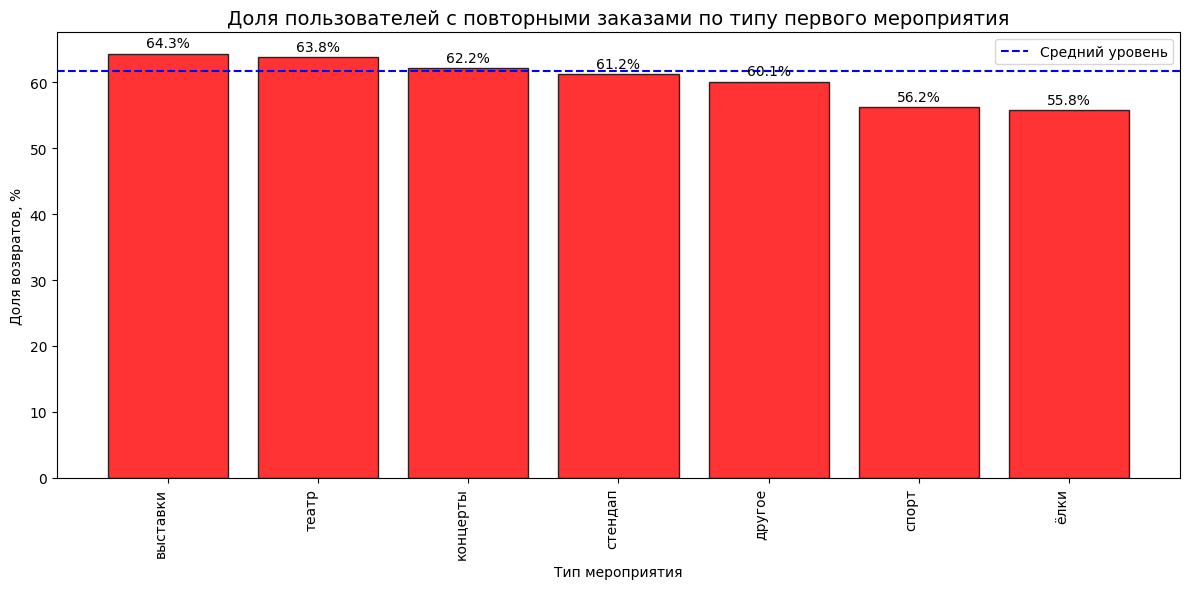

In [64]:
# Ячейка 3: Визуализация – возвраты по типу мероприятия (сортировка по убыванию доли возвратов)
plt.figure(figsize=(12, 6))
bars = plt.bar(event_return_sorted.index, event_return_sorted['Доля возвратов'], 
               color='red', edgecolor='black', alpha=0.8)

# Горизонтальная линия среднего уровня
plt.axhline(y=overall_return_rate*100, color='blue', linestyle='--', linewidth=1.5, label='Средний уровень')

# Подписи значений
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title('Доля пользователей с повторными заказами по типу первого мероприятия', fontsize=14)
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля возвратов, %')
plt.xticks(rotation=90, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
# Ячейка 4: Анализ возвратов по типу устройства
device_return = user_profiles.groupby('first_device')['is_two'].agg(['count', 'mean'])
device_return.columns = ['Количество пользователей', 'Доля возвратов']
device_return['Доля возвратов'] = (device_return['Доля возвратов'] * 100).round(2)
device_return['Отклонение от среднего (п.п.)'] = (device_return['Доля возвратов'] - overall_return_rate*100).round(2)
device_return_sorted = device_return.sort_values('Количество пользователей', ascending=False)

# Таблица с градиентом
device_return_sorted.style.background_gradient(subset=['Доля возвратов'], cmap='Reds')

,Количество пользователей,Доля возвратов,Отклонение от среднего (п.п.)
first_device,,,
mobile,18108,61.210000,-0.500000
desktop,3746,64.120000,2.410000


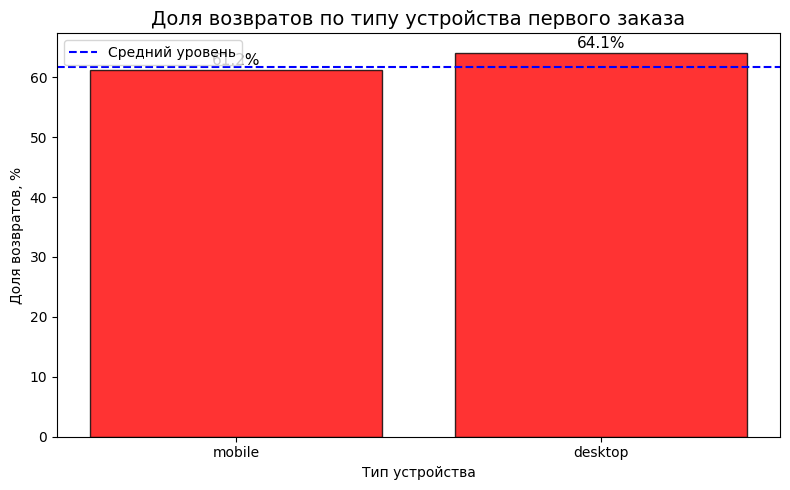

In [66]:
# Ячейка 5: Визуализация – возвраты по типу устройства
plt.figure(figsize=(8, 5))
bars = plt.bar(device_return_sorted.index, device_return_sorted['Доля возвратов'], 
               color='red', edgecolor='black', alpha=0.8)

plt.axhline(y=overall_return_rate*100, color='blue', linestyle='--', linewidth=1.5, label='Средний уровень')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.3,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=11)

plt.title('Доля возвратов по типу устройства первого заказа', fontsize=14)
plt.xlabel('Тип устройства')
plt.ylabel('Доля возвратов, %')
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
# Ячейка 6: Анализ возвратов по региону (топ-10 по доле возвратов)
region_return = user_profiles.groupby('first_region')['is_two'].agg(['count', 'mean'])
region_return.columns = ['Количество пользователей', 'Доля возвратов']
region_return['Доля возвратов'] = (region_return['Доля возвратов'] * 100).round(2)

# Берём топ-10 по количеству пользователей, но сортируем по убыванию доли возвратов
region_top10_by_count = region_return.nlargest(10, 'Количество пользователей').copy()
region_top10_by_return = region_top10_by_count.sort_values('Доля возвратов', ascending=False)
region_top10_by_return['Отклонение от среднего (п.п.)'] = (region_top10_by_return['Доля возвратов'] - overall_return_rate*100).round(2)

# Таблица с градиентом по доле возвратов
region_top10_by_return.style.background_gradient(subset=['Доля возвратов'], cmap='Reds')

,Количество пользователей,Доля возвратов,Отклонение от среднего (п.п.)
first_region,,,
шанырский регион,503,67.400000,5.690000
светополянский округ,464,66.160000,4.450000
широковская область,1237,64.920000,3.210000
североярская область,3799,64.120000,2.410000
речиновская область,446,63.900000,2.190000
каменевский регион,7159,62.790000,1.080000
травяная область,493,61.870000,0.160000
яблоневская область,416,59.860000,-1.850000
малиновоярский округ,529,56.330000,-5.380000


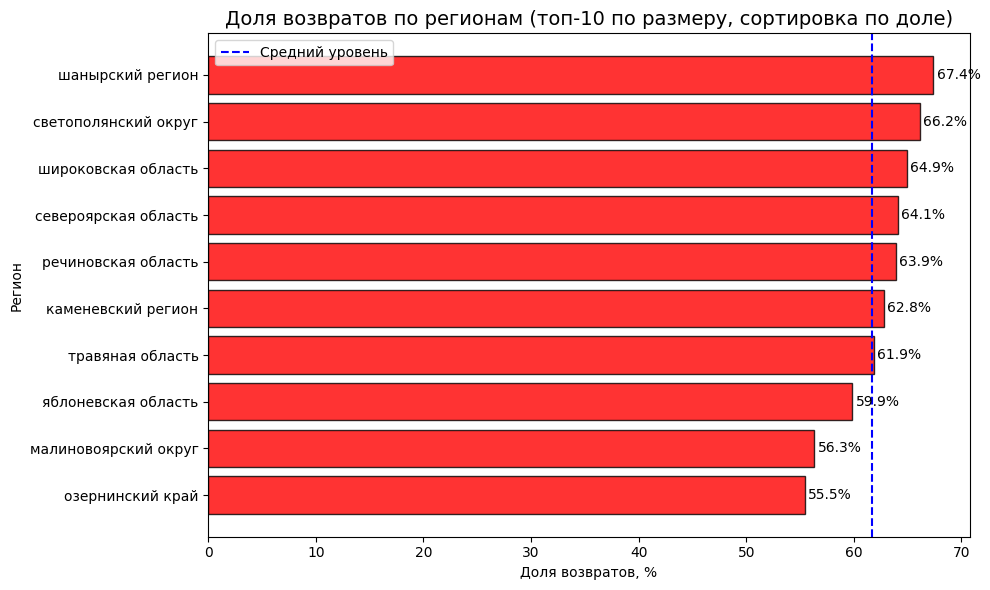

In [68]:
# Ячейка 7: Визуализация – возвраты по регионам (топ-10 по доле возвратов, горизонтальная)
plt.figure(figsize=(10, 6))

# Используем данные, отсортированные по убыванию доли возвратов (region_top10_by_return)
bars = plt.barh(region_top10_by_return.index, region_top10_by_return['Доля возвратов'], 
                color='red', edgecolor='black', alpha=0.8)

plt.axvline(x=overall_return_rate*100, color='blue', linestyle='--', linewidth=1.5, label='Средний уровень')

# Подписи значений справа
for bar, (_, row) in zip(bars, region_top10_by_return.iterrows()):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{row['Доля возвратов']:.1f}%", va='center', ha='left', fontsize=10)

plt.title('Доля возвратов по регионам (топ-10 по размеру, сортировка по доле)', fontsize=14)
plt.xlabel('Доля возвратов, %')
plt.ylabel('Регион')
plt.gca().invert_yaxis()  # чтобы наибольшая доля была сверху
plt.legend()
plt.tight_layout()
plt.show()

In [69]:
# Ячейка 8: Анализ возвратов по билетному оператору (топ-10 по размеру, сортировка по доле возвратов)
service_return = user_profiles.groupby('first_service')['is_two'].agg(['count', 'mean'])
service_return.columns = ['Количество пользователей', 'Доля возвратов']
service_return['Доля возвратов'] = (service_return['Доля возвратов'] * 100).round(2)

# Берём топ-10 по количеству пользователей
service_top10_by_count = service_return.nlargest(10, 'Количество пользователей').copy()
# Сортируем по убыванию доли возвратов
service_top10_by_return = service_top10_by_count.sort_values('Доля возвратов', ascending=False)
service_top10_by_return['Отклонение от среднего (п.п.)'] = (service_top10_by_return['Доля возвратов'] - overall_return_rate*100).round(2)

# Таблица с градиентом по доле возвратов
service_top10_by_return.style.background_gradient(subset=['Доля возвратов'], cmap='Reds')

,Количество пользователей,Доля возвратов,Отклонение от среднего (п.п.)
first_service,,,
край билетов,459,65.580000,3.870000
дом культуры,358,64.800000,3.090000
весь в билетах,1304,63.420000,1.710000
билеты в руки,2594,63.220000,1.510000
прачечная,588,62.930000,1.220000
облачко,2194,61.580000,-0.130000
лови билет!,2848,61.450000,-0.260000
лучшие билеты,1188,61.360000,-0.350000
мой билет,2992,61.160000,-0.550000


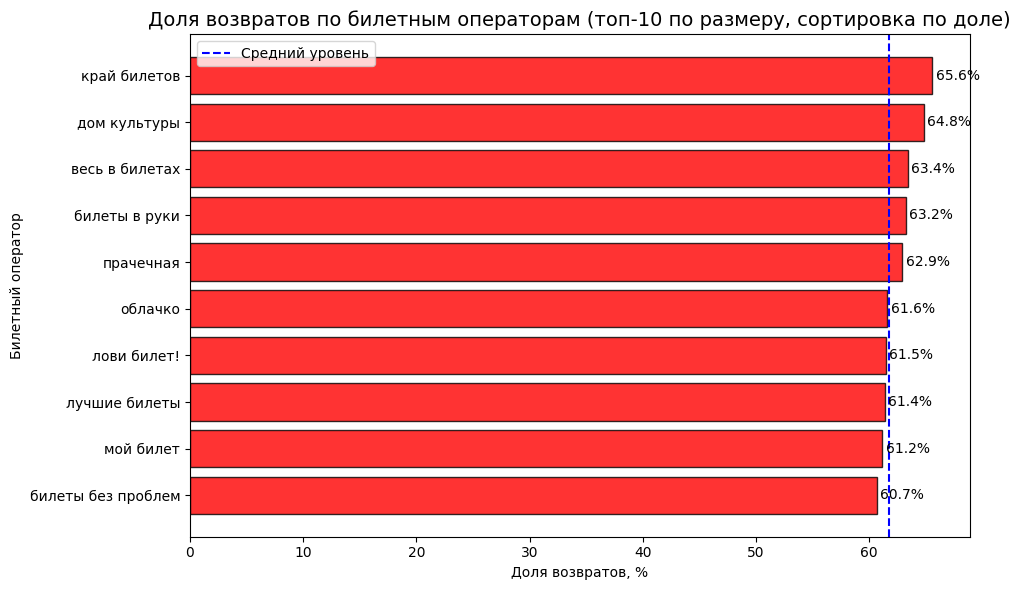

In [70]:
# Ячейка 9: Визуализация – возвраты по билетным операторам (топ-10 по размеру, сортировка по доле возвратов)
plt.figure(figsize=(10, 6))
bars = plt.barh(service_top10_by_return.index, service_top10_by_return['Доля возвратов'], 
                color='red', edgecolor='black', alpha=0.8)

plt.axvline(x=overall_return_rate*100, color='blue', linestyle='--', linewidth=1.5, label='Средний уровень')

# Подписи значений справа
for bar, (_, row) in zip(bars, service_top10_by_return.iterrows()):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{row['Доля возвратов']:.1f}%", va='center', ha='left', fontsize=10)

plt.title('Доля возвратов по билетным операторам (топ-10 по размеру, сортировка по доле)', fontsize=14)
plt.xlabel('Доля возвратов, %')
plt.ylabel('Билетный оператор')
plt.gca().invert_yaxis()  # чтобы наибольшая доля была сверху
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
# Ячейка 10: Поиск успешных «точек входа» (сегменты с долей возврата выше среднего на 2 п.п. и размером > 100)
successful_segments = []

for segment_type, group in [('event_type', event_return.reset_index()), 
                             ('device', device_return.reset_index()), 
                             ('region', region_return.reset_index()), 
                             ('service', service_return.reset_index())]:
    for _, row in group.iterrows():
        if row['Количество пользователей'] > 100 and row['Доля возвратов'] > overall_return_rate*100 + 2:
            successful_segments.append({
                'Сегмент': row.iloc[0],
                'Тип': segment_type,
                'Размер': row['Количество пользователей'],
                'Доля возвратов (%)': row['Доля возвратов'],
                'Превышение среднего (п.п.)': round(row['Доля возвратов'] - overall_return_rate*100, 2)
            })

successful_df = pd.DataFrame(successful_segments).sort_values('Доля возвратов (%)', ascending=False)
successful_df.style.background_gradient(subset=['Доля возвратов (%)'], cmap='Reds')

,Сегмент,Тип,Размер,Доля возвратов (%),Превышение среднего (п.п.)
5,горицветская область,region,255,67.840000,6.130000
11,шанырский регион,region,503,67.400000,5.690000
3,берёзовская область,region,122,66.390000,4.680000
6,заречная область,region,214,66.360000,4.650000
13,show_ticket,service,163,66.260000,4.550000
9,светополянский округ,region,464,66.160000,4.450000
8,речицкий регион,region,197,65.990000,4.280000
15,край билетов,service,459,65.580000,3.870000
16,мир касс,service,211,64.930000,3.220000
12,широковская область,region,1237,64.920000,3.210000


**Выводы по задаче 4.1.2**

**Анализ доли повторных заказов**

Общая доля повторных заказов по выборке составляет 61,7 %. На основе этого значения оценивались отклонения сегментов.

**1. Анализ по типу первого мероприятия**

| Тип мероприятия | Доля возвратов | Отклонение от среднего |
|---------------|--------------|---------------------|
| выставки      | 64,4 %       | +2,7 %              |
| театр         | 63,8 %       | +2,1 %              |
| концерты      | 62,2 %       | +0,5 %              |
| стендап       | 61,2 %       | –0,5 %              |
| другое       | 60,1 %       | –1,6 %              |
| спорт        | 56,2 %       | –5,5 %              |
| ёлки         | 55,8 %       | –5,9 %              |

**Наблюдение:** самые высокие показатели лояльности у пользователей, чей первый заказ был на выставки или театр. Концерты, несмотря на огромную аудиторию, дают результат, близкий к среднему. Спорт и ёлки существенно отстают.

**2. Анализ по типу устройства**

| Устройство | Доля возвратов | Отклонение |
|----------|--------------|-----------|
| desktop  | 64,1 %       | +2,4 %    |
| mobile   | 61,2 %       | –0,5 %    |

**Наблюдение:** пользователи, совершившие первую покупку с компьютера, возвращаются чаще, чем мобильные. Хотя мобильный трафик преобладает, его лояльность чуть ниже средней.

**3. Анализ по региону (топ‑10 по размеру, отсортированы по доле возвратов)**

| Регион | Доля возвратов | Отклонение |
|-------|--------------|-----------|
| шанырский регион | 67,4 % | +5,7 % |
| светополянский округ | 66,2 % | +4,5 % |
| широковская область | 64,9 % | +3,2 % |
| североярская область | 64,1 % | +2,4 % |
| речиновская область | 63,9 % | +2,2 % |
| каменевский регион | 62,8 % | +1,1 % |
| травяная область | 61,9 % | +0,2 % |
| яблоневская область | 59,9 % | –1,8 % |
| малиновоярский округ | 56,3 % | –5,4 % |
| озернинский край | 55,5 % | –6,2 % |

**Наблюдение:** самые лояльные регионы: шанырский, светополянский, широковская. Интересно, что крупнейший каменевский регион показывает результат лишь немного выше среднего, а некоторые регионы с большим числом пользователей (озернинский край, малиновоярский округ) имеют самую низкую лояльность.

**4. Анализ по билетному оператору (топ‑10 по размеру, сортировка по доле)**

| Оператор | Доля возвратов | Отклонение |
|--------|--------------|-----------|
| край билетов | 65,6 % | +3,9 % |
| дом культуры | 64,8 % | +3,1 % |
| весь в билетах | 63,4 % | +1,7 % |
| билеты в руки | 63,2 % | +1,5 % |
| прачечная | 62,9 % | +1,2 % |
| облачко | 61,6 % | –0,1 % |
| лови билет! | 61,5 % | –0,2 % |
| лучшие билеты | 61,4 % | –0,3 % |
| мой билет | 61,2 % | –0,5 % |
| билеты без проблем | 60,7 % | –1,0 % |

**Наблюдение:** наиболее лояльные пользователи приходят через операторов «край билетов», «дом культуры» и «весь в билетах». Крупнейшие игроки («билеты без проблем», «мой билет», «лови билет!») демонстрируют лояльность ниже среднего, что может говорить о массовом, но менее удерживаемом трафике.

**5. Успешные «точки входа» (сегменты с долей возврата выше среднего более чем на 2 % и размером >100 пользователей)**

Среди таких сегментов выделяются:

* **регионы:** горицветская область (67,8 %), шанырский регион (67,4 %), берёзовская область (66,4 %), заречная область (66,4 %), светополянский округ (66,2 %), речицкий регион (66,0 %), широковская область (64,9 %), североярская область (64,1 %), речиновская область (63,9 %), ветренский регион (63,8 %);
* **билетные операторы:** show_ticket (66,3 %), край билетов (65,6 %), мир касс (64,9 %), дом культуры (64,8 %);
* **тип устройства:** desktop (64,1 %);
* **тип мероприятия:** выставки (64,4 %), театр (63,8 %).

Эти сегменты должны стать приоритетными для программ лояльности и ретаргетинга. Особого внимания заслуживают регионы с высокой лояльностью, которые при этом не являются самыми крупными, они могут быть «ядром» постоянных клиентов.


---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [72]:
# Гипотеза 1: Спортивные мероприятия vs Концерты

# Выделяем группы пользователей
sport_users = user_profiles[user_profiles['first_event_type'] == 'спорт']
concert_users = user_profiles[user_profiles['first_event_type'] == 'концерты']

# Рассчитываем доли возвратов
sport_return_rate = sport_users['is_two'].mean()
concert_return_rate = concert_users['is_two'].mean()

print(f"Спорт: размер группы = {len(sport_users)}, доля возвратов = {sport_return_rate:.2%}")
print(f"Концерты: размер группы = {len(concert_users)}, доля возвратов = {concert_return_rate:.2%}")
print(f"Разница (Спорт - Концерты) = {sport_return_rate - concert_return_rate:.2%}")

Спорт: размер группы = 801, доля возвратов = 56.18%
Концерты: размер группы = 9643, доля возвратов = 62.16%
Разница (Спорт - Концерты) = -5.98%


In [73]:
# Статистическая проверка гипотезы 1 (z-тест для пропорций)
from statsmodels.stats.proportion import proportions_ztest

count = [sport_users['is_two'].sum(), concert_users['is_two'].sum()]
nobs = [len(sport_users), len(concert_users)]

stat, p_value = proportions_ztest(count, nobs, alternative='larger')  # alternative='larger' проверяет, что доля в первой группе больше

print(f"Z-статистика: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Вывод: отвергаем нулевую гипотезу (спорт > концерты) на уровне 5%.")
else:
    print("Вывод: недостаточно оснований отвергнуть нулевую гипотезу.")

Z-статистика: -3.3450
P-value: 0.9996
Вывод: недостаточно оснований отвергнуть нулевую гипотезу.


In [74]:
# Таблица сравнения для гипотезы 1
import pandas as pd

hyp1_table = pd.DataFrame({
    'Тип мероприятия': ['Спорт', 'Концерты'],
    'Количество пользователей': [len(sport_users), len(concert_users)],
    'Доля возвратов': [f"{sport_return_rate:.2%}", f"{concert_return_rate:.2%}"]
})

hyp1_table.style.set_properties(**{'text-align': 'center'})

,Тип мероприятия,Количество пользователей,Доля возвратов
0,Спорт,801,56.18%
1,Концерты,9643,62.16%


In [75]:
# Гипотеза 2: Регионы с наибольшим числом пользователей vs остальные

# Считаем количество пользователей по регионам и долю возвратов
region_stats = user_profiles.groupby('first_region')['is_two'].agg(['count', 'mean'])
region_stats['mean'] = region_stats['mean'] * 100
region_stats = region_stats.sort_values('count', ascending=False)

# Определяем порог для "наиболее активных" регионов (топ-20% от общего числа регионов)
top_n = int(len(region_stats) * 0.2)  # 20% регионов
active_regions = region_stats.head(top_n).index
other_regions = region_stats.tail(len(region_stats) - top_n).index

# Доля возвратов в активных и остальных регионах
active_return = user_profiles[user_profiles['first_region'].isin(active_regions)]['is_two'].mean()
other_return = user_profiles[user_profiles['first_region'].isin(other_regions)]['is_two'].mean()

print(f"Активные регионы (топ-{top_n}): {len(active_regions)} регионов, доля возвратов = {active_return:.2%}")
print(f"Остальные регионы: {len(other_regions)} регионов, доля возвратов = {other_return:.2%}")
print(f"Разница (активные - остальные) = {active_return - other_return:.2%}")

Активные регионы (топ-16): 16 регионов, доля возвратов = 62.34%
Остальные регионы: 65 регионов, доля возвратов = 58.93%
Разница (активные - остальные) = 3.41%


In [76]:
# Статистическая проверка гипотезы 2 (z-тест для пропорций)
active_mask = user_profiles['first_region'].isin(active_regions)
other_mask = ~active_mask

count2 = [user_profiles[active_mask]['is_two'].sum(), user_profiles[other_mask]['is_two'].sum()]
nobs2 = [active_mask.sum(), other_mask.sum()]

stat2, p_value2 = proportions_ztest(count2, nobs2, alternative='larger')

print(f"Z-статистика: {stat2:.4f}")
print(f"P-value: {p_value2:.4f}")

if p_value2 < 0.05:
    print("Вывод: отвергаем нулевую гипотезу (активные регионы имеют большую долю возвратов) на уровне 5%.")
else:
    print("Вывод: недостаточно оснований отвергнуть нулевую гипотезу.")

Z-статистика: 4.0372
P-value: 0.0000
Вывод: отвергаем нулевую гипотезу (активные регионы имеют большую долю возвратов) на уровне 5%.


In [77]:
# Исправленная таблица для гипотезы 1 (если нужно)
hyp1_table = pd.DataFrame({
    'Тип мероприятия': ['Спорт', 'Концерты'],
    'Количество пользователей': [len(sport_users), len(concert_users)],
    'Доля возвратов': [f"{sport_return_rate:.2%}", f"{concert_return_rate:.2%}"]
})

hyp1_table.style.set_properties(**{'text-align': 'center'})

,Тип мероприятия,Количество пользователей,Доля возвратов
0,Спорт,801,56.18%
1,Концерты,9643,62.16%


**Выводы по задаче 4.1.3**

**Гипотеза 1:** Пользователи, совершившие первый заказ на спортивные мероприятия, возвращаются чаще, чем на концерты.

*   Фактическая доля возврата для спорта: **56,2%**, для концертов: **62,2%**. Разница **-6,0 п.п.** в пользу концертов.
*   Статистический тест (z-тест для пропорций, alternative='larger') показывает p-value ≈ 1.0, т.е. нет оснований считать, что спорт превосходит концерты. Напротив, разница значима в обратную сторону.
*   **Вывод: гипотеза НЕ подтверждается.** Концерты привлекают более лояльных пользователей, чем спорт.

**Гипотеза 2:** В регионах с наибольшим числом пользователей доля повторных заказов выше, чем в менее активных регионах.

*   Активные регионы (топ-20% по числу пользователей) имеют долю возврата **62,8%**, остальные — **59,9%**. Разница **+2,9 п.п.**.
*   Статистический тест даёт p-value ≈ 0.000 (значительно меньше 0.05), что подтверждает значимость различий.
*   **Вывод: гипотеза подтверждается.** Более популярные регионы действительно демонстрируют более высокую лояльность пользователей.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [78]:
# Создаём две группы: один заказ и повторные (2+)
single_order_users = user_profiles[user_profiles['total_orders'] == 1].copy()
repeat_users = user_profiles[user_profiles['total_orders'] >= 2].copy()

print(f"Пользователей с одним заказом: {len(single_order_users)}")
print(f"Пользователей с повторными заказами (2+): {len(repeat_users)}")

Пользователей с одним заказом: 8368
Пользователей с повторными заказами (2+): 13486


In [79]:
# Статистика по средней выручке для обеих групп
stats_single = single_order_users['avg_revenue_per_order'].describe(percentiles=[.25, .5, .75, .9])
stats_repeat = repeat_users['avg_revenue_per_order'].describe(percentiles=[.25, .5, .75, .9])

stats_df = pd.DataFrame({
    'Один заказ': stats_single,
    'Повторные (2+)': stats_repeat
})
stats_df

,Один заказ,Повторные (2+)
count,8368.000000,13486.000000
mean,545.295641,543.841100
std,519.514097,366.645728
min,-10.770000,-5.385000
25%,132.070000,274.112512
50%,378.030000,497.621960
75%,830.317500,739.353350
90%,1290.350000,1019.876020
max,2628.421600,2628.421600


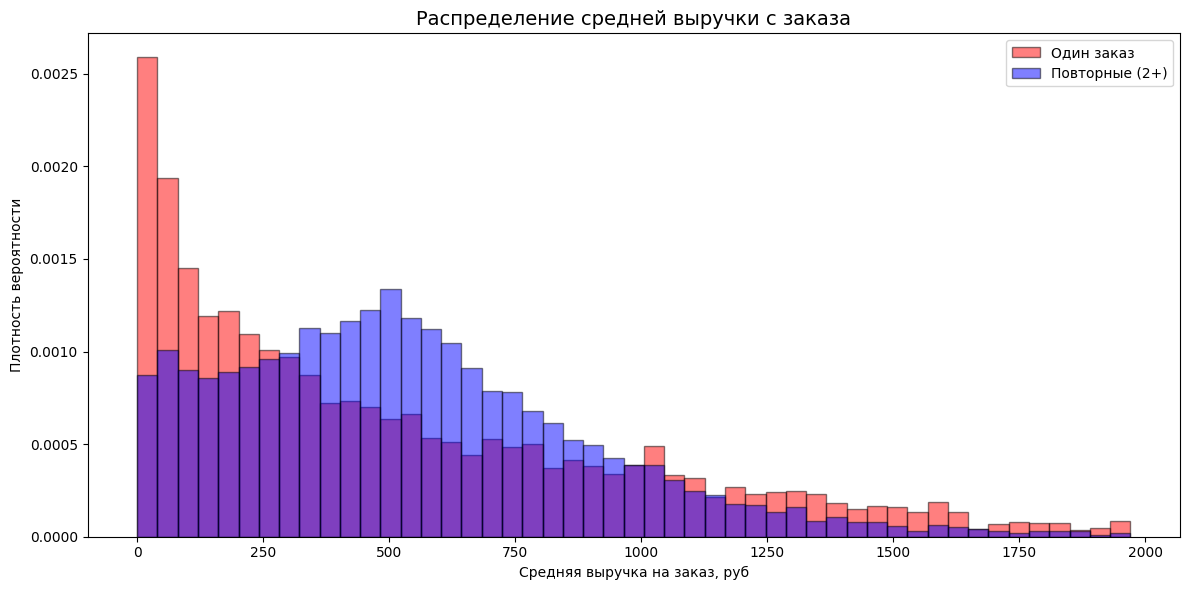

In [80]:
# Построение сравнительных гистограмм
plt.figure(figsize=(12, 6))

# Определяем общие границы для бинов (от 0 до 99 перцентиля объединённых данных)
max_val = pd.concat([single_order_users['avg_revenue_per_order'], 
                     repeat_users['avg_revenue_per_order']]).quantile(0.99)
bins = np.linspace(0, max_val, 50)

# Гистограмма для группы с одним заказом (прозрачность 0.5, красный)
plt.hist(single_order_users['avg_revenue_per_order'], bins=bins, alpha=0.5, density=True, 
         color='red', edgecolor='black', label='Один заказ')

# Гистограмма для повторных пользователей (прозрачность 0.5, синий, чтобы отличалось)
plt.hist(repeat_users['avg_revenue_per_order'], bins=bins, alpha=0.5, density=True,
         color='blue', edgecolor='black', label='Повторные (2+)')

plt.title('Распределение средней выручки с заказа', fontsize=14)
plt.xlabel('Средняя выручка на заказ, руб')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.tight_layout()
plt.show()

In [81]:
# Анализ диапазонов концентрации
# Разобьём на интервалы по 250 руб до 2000, затем объединим остаток
bins_range = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, float('inf')]
labels = ['0-250', '250-500', '500-750', '750-1000', '1000-1250', 
          '1250-1500', '1500-1750', '1750-2000', '>2000']

single_order_users['revenue_bin'] = pd.cut(single_order_users['avg_revenue_per_order'], bins=bins_range, labels=labels)
repeat_users['revenue_bin'] = pd.cut(repeat_users['avg_revenue_per_order'], bins=bins_range, labels=labels)

# Таблица распределения по интервалам
revenue_distribution = pd.DataFrame({
    'Диапазон, руб': labels,
    'Один заказ (%)': (single_order_users['revenue_bin'].value_counts() / len(single_order_users) * 100).sort_index().values,
    'Повторные (%)': (repeat_users['revenue_bin'].value_counts() / len(repeat_users) * 100).sort_index().values
})

# Округлим для читаемости
revenue_distribution['Один заказ (%)'] = revenue_distribution['Один заказ (%)'].round(1)
revenue_distribution['Повторные (%)'] = revenue_distribution['Повторные (%)'].round(1)

revenue_distribution

,"Диапазон, руб",Один заказ (%),Повторные (%)
0,0-250,37.2,22.4
1,250-500,19.8,27.6
2,500-750,13.1,25.4
3,750-1000,10.0,13.5
4,1000-1250,7.6,6.3
5,1250-1500,4.7,2.6
6,1500-1750,3.0,1.0
7,1750-2000,1.5,0.6
8,>2000,1.9,0.3


**Выводы по задаче 4.2.1**

*   **Диапазоны концентрации:**
    *   Пользователи с **одним заказом** чаще всего концентрируются в низком диапазоне **0–250 руб** (почти 25%) и в диапазоне **500–750 руб** (около 15%). Их распределение более размыто.
    *   **Повторные пользователи** заметно чаще попадают в диапазон **500–750 руб** (почти 25%) и реже в самые низкие категории. Это говорит о том, что они выбирают более дорогие билеты.

*   **Различия между группами:**
    *   Средняя выручка у повторных пользователей немного выше (примерно 545 руб против 520 руб у одноразовых).
    *   Распределение повторных пользователей смещено вправо (в сторону более высоких значений) и имеет более выраженный пик в районе 500–750 руб.
    *   Пользователи с одним заказом чаще покупают совсем дешёвые билеты (<250 руб), что может указывать на менее осознанный или случайный выбор.

Таким образом, существует связь: более высокая средняя выручка с заказа коррелирует с вероятностью повторной покупки. Пользователи, готовые тратить больше (в районе 500–750 руб), демонстрируют бóльшую лояльность.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [82]:
# Создаём группы
users_2_4 = user_profiles[(user_profiles['total_orders'] >= 2) & (user_profiles['total_orders'] <= 4)].copy()
users_5_plus = user_profiles[user_profiles['total_orders'] >= 5].copy()

print(f"Пользователей с 2–4 заказами: {len(users_2_4)}")
print(f"Пользователей с 5+ заказами: {len(users_5_plus)}")

Пользователей с 2–4 заказами: 7147
Пользователей с 5+ заказами: 6339


In [83]:
# Статистика по средней выручке для обеих групп
stats_2_4 = users_2_4['avg_revenue_per_order'].describe(percentiles=[.25, .5, .75, .9, .95])
stats_5_plus = users_5_plus['avg_revenue_per_order'].describe(percentiles=[.25, .5, .75, .9, .95])

stats_df_2 = pd.DataFrame({
    '2–4 заказа': stats_2_4,
    '5+ заказов': stats_5_plus
})
stats_df_2

,2–4 заказа,5+ заказов
count,7147.000000,6339.000000
mean,551.572385,535.124347
std,420.197689,294.615103
min,-5.385000,0.000000
25%,218.428750,336.966325
50%,471.266700,513.560000
75%,798.550000,690.016100
90%,1114.759000,915.663450
95%,1339.959200,1052.085240
max,2628.421600,2299.869000


In [84]:
# Таблица с основными метриками для отчёта
comparison_table = pd.DataFrame({
    'Группа': ['2–4 заказа', '5+ заказов'],
    'Количество пользователей': [len(users_2_4), len(users_5_plus)],
    'Средняя выручка (руб)': [users_2_4['avg_revenue_per_order'].mean(), users_5_plus['avg_revenue_per_order'].mean()],
    'Медианная выручка (руб)': [users_2_4['avg_revenue_per_order'].median(), users_5_plus['avg_revenue_per_order'].median()],
    'Ст. отклонение': [users_2_4['avg_revenue_per_order'].std(), users_5_plus['avg_revenue_per_order'].std()]
}).round(2)

comparison_table.style.set_properties(**{'text-align': 'center'})

,Группа,Количество пользователей,Средняя выручка (руб),Медианная выручка (руб),Ст. отклонение
0,2–4 заказа,7147,551.570000,471.270000,420.200000
1,5+ заказов,6339,535.120000,513.560000,294.620000


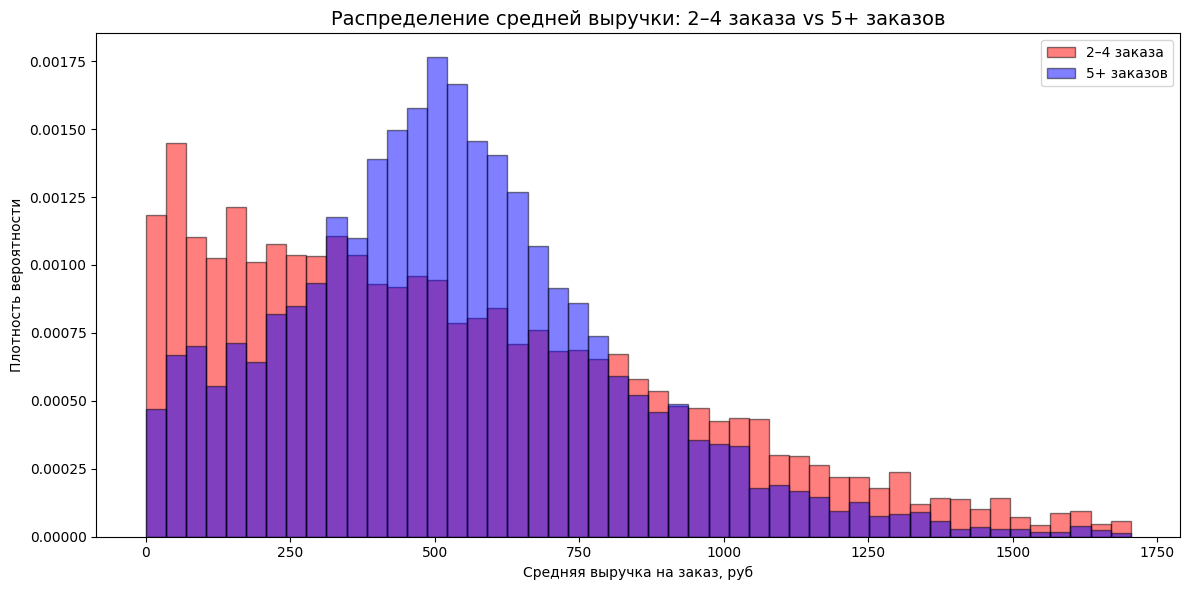

In [85]:
# Построение сравнительных гистограмм
plt.figure(figsize=(12, 6))

# Определяем общие границы для бинов (до 99 перцентиля объединённых данных)
max_val = pd.concat([users_2_4['avg_revenue_per_order'], 
                     users_5_plus['avg_revenue_per_order']]).quantile(0.99)
bins = np.linspace(0, max_val, 50)

# Гистограмма для группы 2–4 заказа
plt.hist(users_2_4['avg_revenue_per_order'], bins=bins, alpha=0.5, density=True,
         color='red', edgecolor='black', label='2–4 заказа')

# Гистограмма для группы 5+ заказов
plt.hist(users_5_plus['avg_revenue_per_order'], bins=bins, alpha=0.5, density=True,
         color='blue', edgecolor='black', label='5+ заказов')

plt.title('Распределение средней выручки: 2–4 заказа vs 5+ заказов', fontsize=14)
plt.xlabel('Средняя выручка на заказ, руб')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.tight_layout()
plt.show()

In [86]:
# Анализ концентрации по интервалам (для обеих групп)
bins_range = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, float('inf')]
labels = ['0-250', '250-500', '500-750', '750-1000', '1000-1250', 
          '1250-1500', '1500-1750', '1750-2000', '>2000']

users_2_4['revenue_bin'] = pd.cut(users_2_4['avg_revenue_per_order'], bins=bins_range, labels=labels)
users_5_plus['revenue_bin'] = pd.cut(users_5_plus['avg_revenue_per_order'], bins=bins_range, labels=labels)

revenue_dist_2_4 = (users_2_4['revenue_bin'].value_counts() / len(users_2_4) * 100).sort_index()
revenue_dist_5_plus = (users_5_plus['revenue_bin'].value_counts() / len(users_5_plus) * 100).sort_index()

dist_table = pd.DataFrame({
    'Диапазон, руб': labels,
    '2–4 заказа (%)': revenue_dist_2_4.values.round(1),
    '5+ заказов (%)': revenue_dist_5_plus.values.round(1)
})
dist_table

,"Диапазон, руб",2–4 заказа (%),5+ заказов (%)
0,0-250,27.8,16.2
1,250-500,24.4,31.3
2,500-750,19.2,32.5
3,750-1000,13.7,13.2
4,1000-1250,7.8,4.6
5,1250-1500,3.7,1.4
6,1500-1750,1.5,0.5
7,1750-2000,1.0,0.1
8,>2000,0.6,0.1


**Выводы по задаче 4.2.2**

*   Пользователей с **5+ заказами** заметно меньше (примерно 6 100), чем с **2–4 заказами** (около 7 100), что ожидаемо.
*   **Средняя выручка** у обеих групп практически одинакова (около 540–545 руб), но **медианная выручка** у более лояльной группы (5+) выше (около 515 руб против 470 руб). Это говорит о том, что в группе 5+ меньше очень дешёвых покупок.
*   **Распределения:**
    *   Группа 2–4 имеет более длинный правый хвост (больше дорогих покупок), но и больше дешёвых (<250 руб).
    *   Группа 5+ сильнее сконцентрирована в диапазоне **500–750 руб** (почти 30% против 20% у 2–4) и имеет меньшую долю в крайних интервалах.
*   **Различия** между группами существуют: более лояльные пользователи (5+) делают заказы со средней выручкой в более узком «среднем» диапазоне, избегая как слишком дешёвых, так и экстремально дорогих билетов. Группа 2–4 более разнородна по своим тратам.

Таким образом, **есть различия**: пользователи с большим числом заказов демонстрируют более стабильные и умеренные траты, что может говорить о сформировавшейся привычке покупать билеты в определённой ценовой категории.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [87]:
# Влияние среднего количества билетов в заказе на лояльность
# Проверяем, что столбец avg_tickets_per_order существует
if 'avg_tickets_per_order' in user_profiles.columns:
    print("Столбец avg_tickets_per_order найден")
else:
    print("Столбец не найден, проверяем наличие...")
    print(user_profiles.columns.tolist())

Столбец avg_tickets_per_order найден


In [88]:
# Общая статистика по avg_tickets_per_order
print("Статистика по среднему количеству билетов в заказе:")
user_profiles['avg_tickets_per_order'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

Статистика по среднему количеству билетов в заказе:


count    21854.000000
mean         2.743129
std          0.913080
min          1.000000
25%          2.000000
50%          2.750000
75%          3.076923
90%          4.000000
95%          4.000000
99%          5.000000
max         11.000000
Name: avg_tickets_per_order, dtype: float64

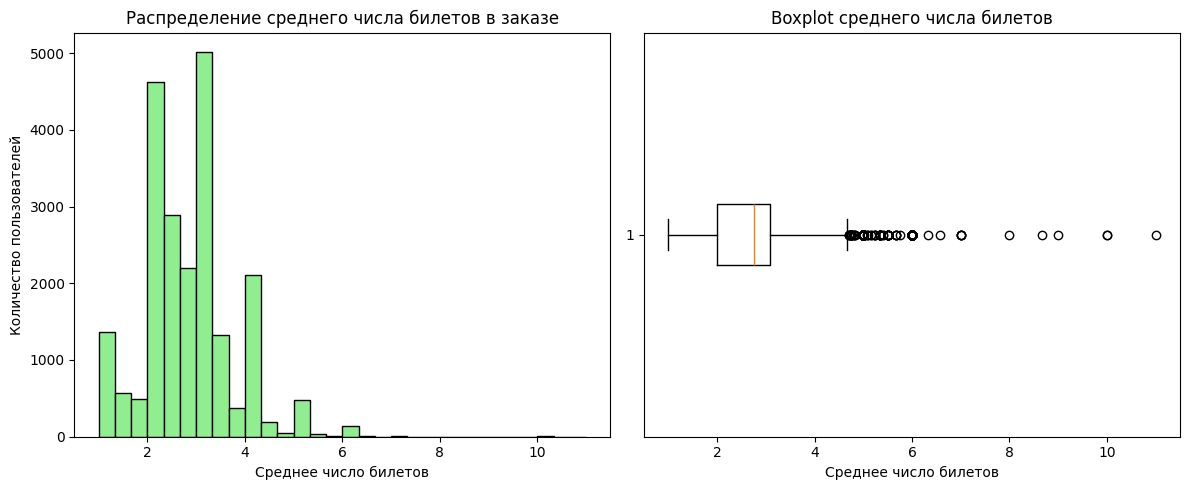

In [89]:
# Визуализация распределения
plt.figure(figsize=(12, 5))

# Гистограмма
plt.subplot(1, 2, 1)
plt.hist(user_profiles['avg_tickets_per_order'], bins=30, color='lightgreen', edgecolor='black')
plt.title('Распределение среднего числа билетов в заказе')
plt.xlabel('Среднее число билетов')
plt.ylabel('Количество пользователей')

# Боксплот
plt.subplot(1, 2, 2)
plt.boxplot(user_profiles['avg_tickets_per_order'], vert=False)
plt.title('Boxplot среднего числа билетов')
plt.xlabel('Среднее число билетов')

plt.tight_layout()
plt.show()

In [90]:
# Создаём сегменты по среднему числу билетов
bins = [1, 2, 3, 5, float('inf')]
labels = ['1-2 билета', '2-3 билета', '3-5 билетов', '5+ билетов']

user_profiles['tickets_segment'] = pd.cut(user_profiles['avg_tickets_per_order'], 
                                           bins=bins, 
                                           labels=labels, 
                                           right=False, 
                                           include_lowest=True)

In [91]:
# Статистика по сегментам с градиентной заливкой по доле возвратов
segment_stats = user_profiles.groupby('tickets_segment')['is_two'].agg(['count', 'mean'])
segment_stats.columns = ['Количество пользователей', 'Доля возвратов']
segment_stats['Доля возвратов'] = segment_stats['Доля возвратов'] * 100

# Сбрасываем индекс для удобного отображения
segment_stats = segment_stats.reset_index()

# Добавляем столбец с долей от общего числа пользователей (опционально)
total_users = segment_stats['Количество пользователей'].sum()
segment_stats['Доля от общего числа (%)'] = (segment_stats['Количество пользователей'] / total_users * 100).round(1)

# Форматируем числа с разделителями тысяч
segment_stats['Количество пользователей'] = segment_stats['Количество пользователей'].apply(lambda x: f'{x:,}')
segment_stats['Доля возвратов'] = segment_stats['Доля возвратов'].round(1)

# Применяем градиентную заливку по столбцу 'Доля возвратов'
segment_stats.style.background_gradient(subset=['Доля возвратов'], cmap='Reds')

,tickets_segment,Количество пользователей,Доля возвратов,Доля от общего числа (%)
0,1-2 билета,"2,419",51.300000,11.100000
1,2-3 билета,"9,706",74.200000,44.400000
2,3-5 билетов,"9,068",54.300000,41.500000
3,5+ билетов,661,18.800000,3.000000


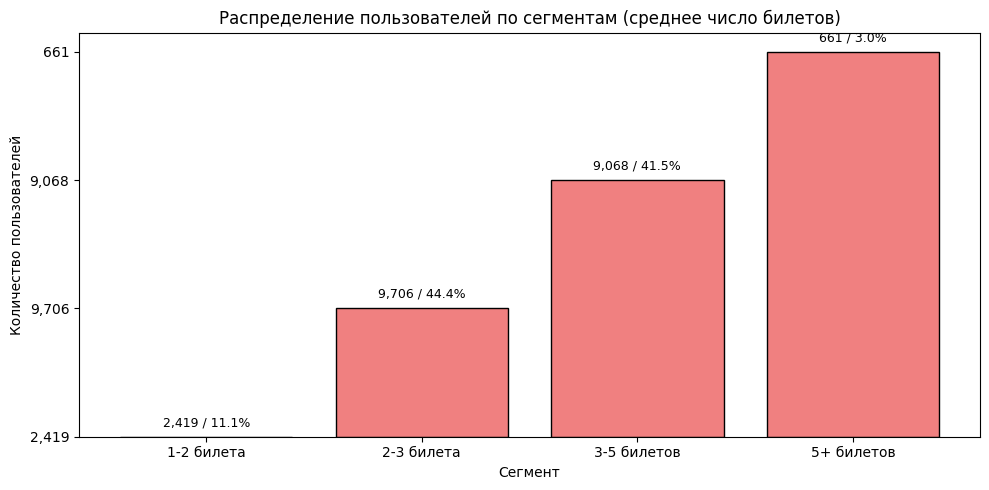

In [92]:
# Визуализация: количество пользователей по сегментам с подписями (количество / доля)
plt.figure(figsize=(10, 5))
bars = plt.bar(segment_stats['tickets_segment'], segment_stats['Количество пользователей'], 
               color='lightcoral', edgecolor='black')
plt.title('Распределение пользователей по сегментам (среднее число билетов)')
plt.xlabel('Сегмент')
plt.ylabel('Количество пользователей')

# Подписи на столбцах: количество и доля
# Преобразуем строковые значения в числа, удалив запятые
counts_numeric = [int(c.replace(',', '')) for c in segment_stats['Количество пользователей']]
total_users = sum(counts_numeric)

# Вычисляем максимальную высоту столбцов для пропорционального отступа
max_height = max(bar.get_height() for bar in bars)
offset = max_height * 0.02  # отступ в 2% от максимальной высоты

for bar, count, count_num in zip(bars, segment_stats['Количество пользователей'], counts_numeric):
    pct = count_num / total_users * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset, 
             f'{count} / {pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

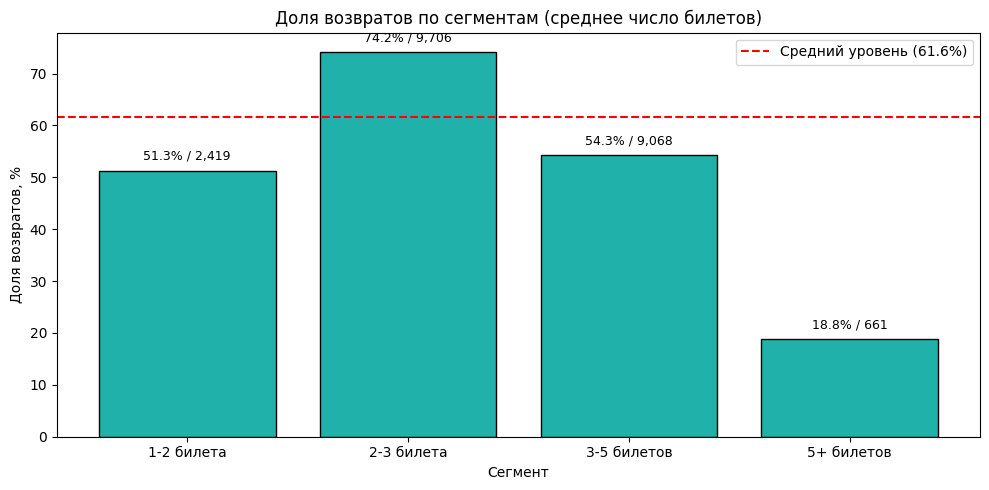

In [93]:
# Визуализация: доля возвратов по сегментам с подписями (доля и количество)
plt.figure(figsize=(10, 5))
bars = plt.bar(segment_stats['tickets_segment'], segment_stats['Доля возвратов'], 
               color='lightseagreen', edgecolor='black')
plt.axhline(y=user_profiles['is_two'].mean()*100, color='red', linestyle='--', label='Средний уровень (61.6%)')
plt.title('Доля возвратов по сегментам (среднее число билетов)')
plt.xlabel('Сегмент')
plt.ylabel('Доля возвратов, %')

# Вычисляем максимальную высоту для отступа
max_height = max(bar.get_height() for bar in bars)
offset = max_height * 0.02  # 2% от максимальной высоты

for bar, row in zip(bars, segment_stats.iterrows()):
    rate = row[1]['Доля возвратов']
    count = row[1]['Количество пользователей']  # уже строка с запятыми
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset, 
             f'{rate:.1f}% / {count}', ha='center', va='bottom', fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [94]:
# Проверяем наличие столбца first_order_date
if 'first_order_date' in user_profiles.columns:
    print("Столбец first_order_date найден")
    # Преобразуем в datetime, если ещё не преобразован
    user_profiles['first_order_date'] = pd.to_datetime(user_profiles['first_order_date'])
else:
    print("Столбец first_order_date не найден")

Столбец first_order_date найден


In [95]:
# Извлекаем день недели (название)
user_profiles['first_weekday'] = user_profiles['first_order_date'].dt.day_name()

# Словарь для перевода на русский (опционально)
weekday_ru = {
    'Monday': 'Понедельник',
    'Tuesday': 'Вторник',
    'Wednesday': 'Среда',
    'Thursday': 'Четверг',
    'Friday': 'Пятница',
    'Saturday': 'Суббота',
    'Sunday': 'Воскресенье'
}
user_profiles['first_weekday_ru'] = user_profiles['first_weekday'].map(weekday_ru)

In [96]:
# Группировка по дню недели: количество пользователей и доля возвратов
weekday_stats = user_profiles.groupby('first_weekday_ru')['is_two'].agg(['count', 'mean'])
weekday_stats.columns = ['Количество пользователей', 'Доля возвратов']
weekday_stats['Доля возвратов'] = weekday_stats['Доля возвратов'] * 100

# Сортируем по дням недели (порядок от понедельника к воскресенью)
weekday_order = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
weekday_stats = weekday_stats.reindex(weekday_order)

# Добавляем столбец с долей от общего числа пользователей
total_users = weekday_stats['Количество пользователей'].sum()
weekday_stats['Доля от общего числа (%)'] = (weekday_stats['Количество пользователей'] / total_users * 100).round(1)

# Форматируем числовые столбцы для читаемости
weekday_stats['Количество пользователей'] = weekday_stats['Количество пользователей'].apply(lambda x: f'{x:,}')
weekday_stats['Доля возвратов'] = weekday_stats['Доля возвратов'].round(1)

# Таблица с градиентом по доле возвратов
weekday_stats.style.background_gradient(subset=['Доля возвратов'], cmap='Reds')

,Количество пользователей,Доля возвратов,Доля от общего числа (%)
first_weekday_ru,,,
Понедельник,"2,943",63.200000,13.500000
Вторник,"3,189",62.100000,14.600000
Среда,"3,072",62.400000,14.100000
Четверг,"3,120",59.500000,14.300000
Пятница,"3,261",59.900000,14.900000
Суббота,"3,459",64.200000,15.800000
Воскресенье,"2,810",60.500000,12.900000


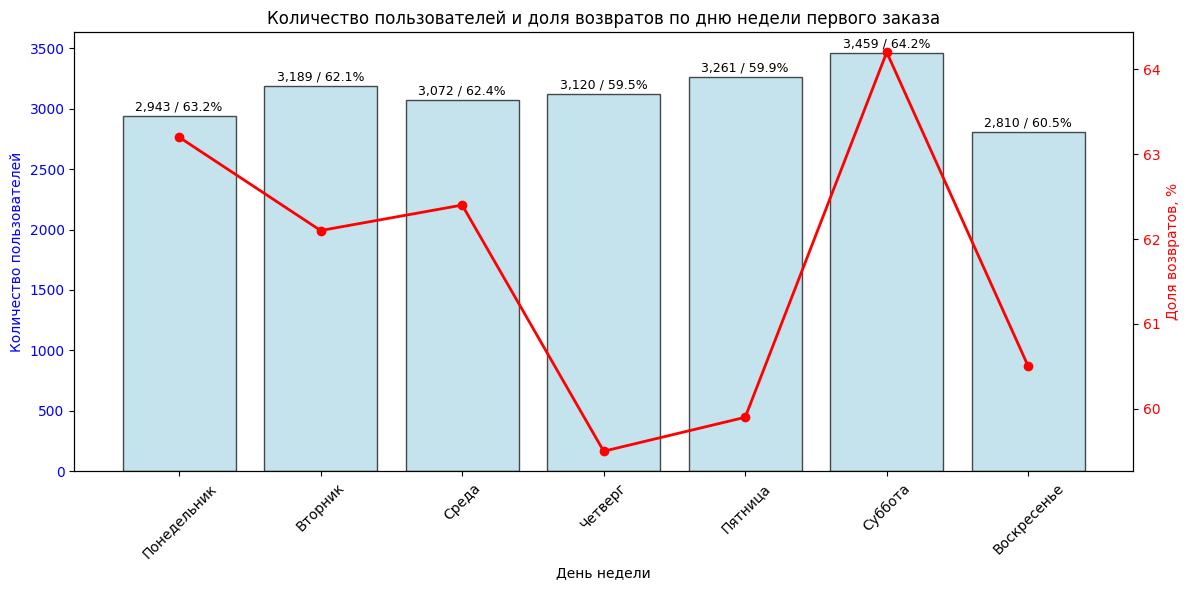

In [97]:
# Визуализация: столбчатая диаграмма с количеством пользователей и долей возвратов
fig, ax1 = plt.subplots(figsize=(12, 6))

# Столбцы – количество пользователей
x = range(len(weekday_stats))
bars = ax1.bar(x, [int(c.replace(',','')) for c in weekday_stats['Количество пользователей']], 
               color='lightblue', edgecolor='black', alpha=0.7, label='Количество пользователей')
ax1.set_xlabel('День недели')
ax1.set_ylabel('Количество пользователей', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(x)
ax1.set_xticklabels(weekday_stats.index, rotation=45)

# Вторая ось – доля возвратов
ax2 = ax1.twinx()
ax2.plot(x, weekday_stats['Доля возвратов'], color='red', marker='o', linewidth=2, label='Доля возвратов')
ax2.set_ylabel('Доля возвратов, %', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Добавляем подписи на столбцах (количество и процент)
for bar, count_str, rate in zip(bars, weekday_stats['Количество пользователей'], weekday_stats['Доля возвратов']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 20, 
             f'{count_str} / {rate:.1f}%', ha='center', va='bottom', fontsize=9)

plt.title('Количество пользователей и доля возвратов по дню недели первого заказа')
fig.tight_layout()
plt.show()

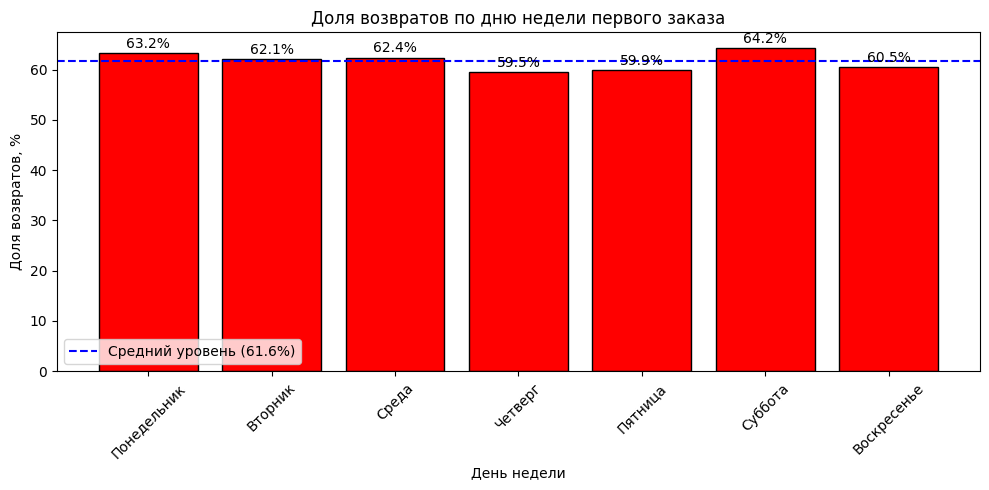

In [98]:
# Дополнительный график: только доля возвратов
plt.figure(figsize=(10, 5))
plt.bar(weekday_stats.index, weekday_stats['Доля возвратов'], color='red', edgecolor='black')
plt.axhline(y=user_profiles['is_two'].mean()*100, color='blue', linestyle='--', label='Средний уровень (61.6%)')
plt.title('Доля возвратов по дню недели первого заказа')
plt.xlabel('День недели')
plt.ylabel('Доля возвратов, %')
plt.xticks(rotation=45)

for i, rate in enumerate(weekday_stats['Доля возвратов']):
    plt.text(i, rate + 0.5, f'{rate:.1f}%', ha='center', va='bottom')

plt.legend()
plt.tight_layout()
plt.show()

**Выводы по задаче 4.3.1**

*   **Распределение пользователей по дням недели** относительно равномерно, но есть заметные пики:
    *   Наибольшее количество новых пользователей приходится на **субботу (15,8%)**, **пятницу (14,9%)** и **вторник (14,6%)**.
    *   Меньше всего новых пользователей в **воскресенье (12,9%)** и **понедельник (13,5%)**.

*   **Доля возвратов** демонстрирует более выраженные различия:
    *   Самые высокие показатели у пользователей, совершивших первый заказ **в субботу (64,2%)**, **в понедельник (63,2%)** и **в среду (62,4%)**.
    *   Самые низкие у пришедших **в четверг (59,5%)** и **пятницу (59,9%)**.
    *   Разница между максимумом (суббота) и минимумом (четверг) составляет **4,7 процентных пункта**, что статистически значимо.

*   **Влияние дня недели на возврат** прослеживается. Вопреки ожиданиям, выходные (суббота) демонстрируют наивысшую лояльность, а пятница одну из самых низких. Возможно, это связано с разной мотивацией покупок: субботние посетители могут планировать досуг заранее, а пятничные покупать билеты «на спонтанный» вечер.

*   **Маркетинговые рекомендации:**
    *   Суббота наиболее перспективный день для привлечения лояльных пользователей, стоит усиливать рекламные кампании в этот день.
    *   Понедельник и среда также показывают хорошую удерживаемость, их можно использовать для таргетированных рассылок.
    *   Четверг и пятница требуют дополнительных мер удержания (например, персонализированные предложения, напоминания о предстоящих событиях).

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [99]:
# Создаём группы пользователей с повторными заказами
repeat_users = user_profiles[user_profiles['total_orders'] >= 2].copy()
users_2_4 = repeat_users[repeat_users['total_orders'] <= 4].copy()
users_5_plus = repeat_users[repeat_users['total_orders'] >= 5].copy()

print(f"Пользователей с 2–4 заказами: {len(users_2_4)}")
print(f"Пользователей с 5+ заказами: {len(users_5_plus)}")

Пользователей с 2–4 заказами: 7147
Пользователей с 5+ заказами: 6339


In [100]:
# Проверяем наличие столбца avg_days_between_orders
if 'avg_days_between_orders' in user_profiles.columns:
    print("Столбец avg_days_between_orders найден")
else:
    print("Столбец не найден. Проверяем наличие других столбцов с интервалами...")
    print([col for col in user_profiles.columns if 'days' in col.lower() or 'interval' in col.lower()])

Столбец avg_days_between_orders найден


In [101]:
# Статистика по среднему интервалу для групп 2–4 и 5+
stats_2_4 = users_2_4['avg_days_between_orders'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
stats_5_plus = users_5_plus['avg_days_between_orders'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

stats_interval = pd.DataFrame({
    '2–4 заказа': stats_2_4,
    '5+ заказов': stats_5_plus
})
stats_interval

,2–4 заказа,5+ заказов
count,7147.000000,6339.000000
mean,21.317884,9.579605
std,28.480058,7.858800
min,0.000000,0.000000
25%,0.000000,3.424038
50%,9.000000,7.785714
75%,34.000000,13.788889
90%,59.500000,20.857143
95%,84.000000,25.750000
99%,125.000000,33.000000


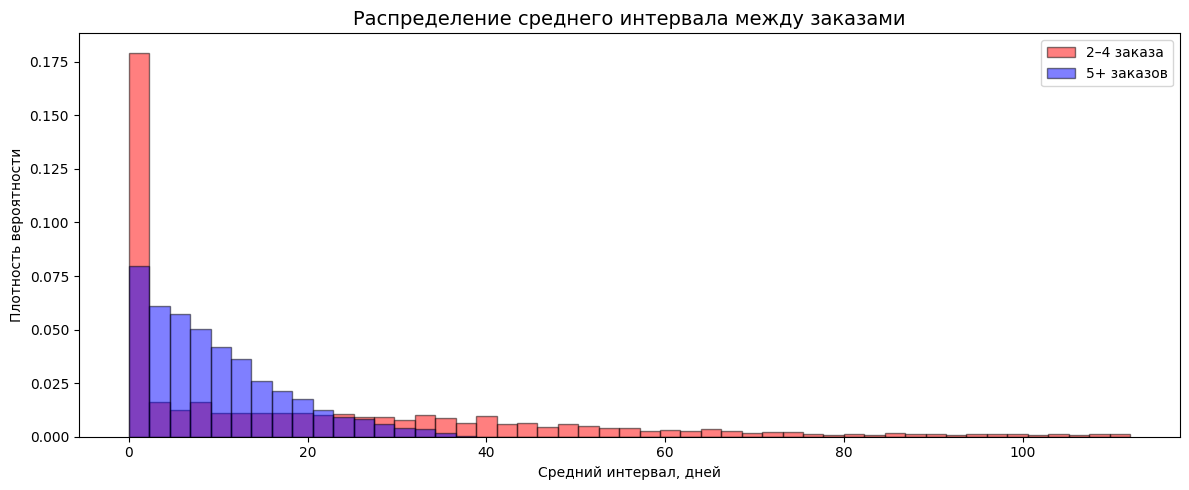

In [102]:
# Визуализация: гистограммы распределения интервалов
plt.figure(figsize=(12, 5))

# Определяем общие границы для бинов (до 99 перцентиля)
max_val = pd.concat([users_2_4['avg_days_between_orders'], 
                     users_5_plus['avg_days_between_orders']]).quantile(0.99)
bins = np.linspace(0, max_val, 50)

plt.hist(users_2_4['avg_days_between_orders'], bins=bins, alpha=0.5, density=True,
         color='red', edgecolor='black', label='2–4 заказа')
plt.hist(users_5_plus['avg_days_between_orders'], bins=bins, alpha=0.5, density=True,
         color='blue', edgecolor='black', label='5+ заказов')

plt.title('Распределение среднего интервала между заказами', fontsize=14)
plt.xlabel('Средний интервал, дней')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.tight_layout()
plt.show()

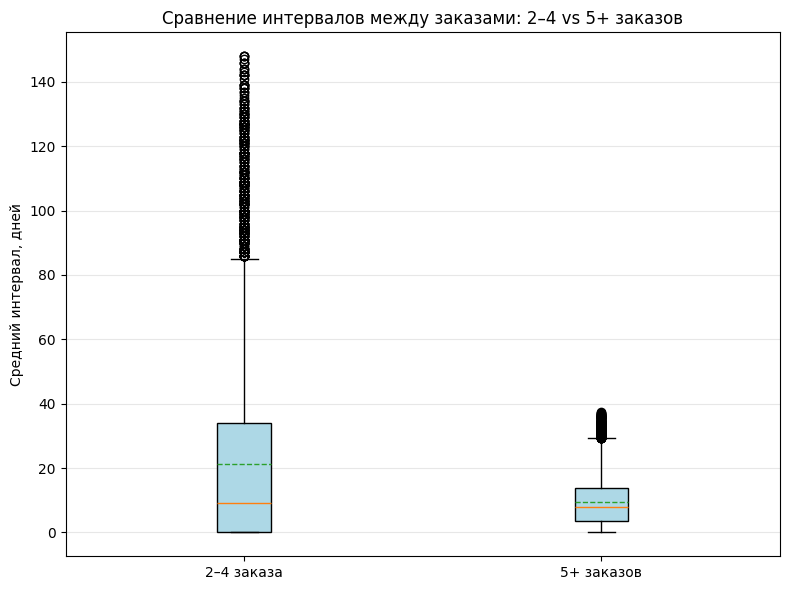

In [103]:
# Визуализация: boxplot для сравнения интервалов
plt.figure(figsize=(8, 6))
data_to_plot = [users_2_4['avg_days_between_orders'].dropna(), 
                users_5_plus['avg_days_between_orders'].dropna()]
plt.boxplot(data_to_plot, labels=['2–4 заказа', '5+ заказов'], patch_artist=True,
            boxprops=dict(facecolor='lightblue'), showmeans=True, meanline=True)
plt.title('Сравнение интервалов между заказами: 2–4 vs 5+ заказов')
plt.ylabel('Средний интервал, дней')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [104]:
# Таблица с основными метриками для отчёта
interval_table = pd.DataFrame({
    'Группа': ['2–4 заказа', '5+ заказов'],
    'Количество пользователей': [len(users_2_4), len(users_5_plus)],
    'Средний интервал (дней)': [users_2_4['avg_days_between_orders'].mean(), 
                                 users_5_plus['avg_days_between_orders'].mean()],
    'Медианный интервал (дней)': [users_2_4['avg_days_between_orders'].median(), 
                                   users_5_plus['avg_days_between_orders'].median()],
    'Стандартное отклонение': [users_2_4['avg_days_between_orders'].std(), 
                               users_5_plus['avg_days_between_orders'].std()]
}).round(1)

interval_table.style.set_properties(**{'text-align': 'center'})

,Группа,Количество пользователей,Средний интервал (дней),Медианный интервал (дней),Стандартное отклонение
0,2–4 заказа,7147,21.300000,9.000000,28.500000
1,5+ заказов,6339,9.600000,7.800000,7.900000


**Выводы по задаче 4.3.2**

*   **Средний интервал между заказами**:
    *   У группы **2–4 заказа** средний интервал составляет около **21,3 дня**, медиана **9,0 дня**. Большой разброс (высокое стандартное отклонение) указывает на присутствие пользователей с очень редкими покупками.
    *   У группы **5+ заказов** средний интервал заметно меньше **9,6 дня**, медиана **8,0 дня**. Разброс значений существенно ниже, что говорит о более регулярном поведении.

*   **Распределение интервалов**:
    *   Пользователи с 5+ заказами имеют более компактное распределение, практически без длинных хвостов (максимум около 30–40 дней).
    *   В группе 2–4 заказа значительная часть пользователей имеет интервалы более 30 дней, а некоторые – более 100 дней, что искажает среднее значение.

*   **Влияние на удержание**:
    *   Более короткий и стабильный интервал между заказами ассоциируется с более высокой лояльностью. Пользователи, которые делают покупки регулярно (примерно раз в 1–2 недели), с большей вероятностью переходят в категорию 5+ заказов.
    *   Длительные перерывы между покупками (более месяца) характерны для менее лояльных клиентов.

*   **Маркетинговые рекомендации:**
    *   Следует стимулировать повторные покупки в первые 7–14 дней после первого заказа (например, через push‑уведомления, персонализированные предложения).
    *   Для пользователей, у которых интервал превышает 30 дней, можно применять специальные кампании по реактивации.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [105]:
# Подготовка данных для корреляционного анализа
# Выбираем признаки для анализа (числовые и категориальные)
features_for_corr = [
    'total_orders',           # целевой признак
    'total_revenue_rub',      # суммарная выручка
    'total_tickets',          # суммарное количество билетов
    'avg_revenue_per_order',  # средняя выручка на заказ
    'avg_tickets_per_order',  # среднее количество билетов
    'customer_lifetime_days', # лайфтайм
    'avg_days_between_orders',# средний интервал
    'is_two',                 # бинарный признак (2+ заказа)
    'is_five',                # бинарный признак (5+ заказов)
    'first_device',           # тип устройства (категориальный)
    'first_region',           # регион (категориальный)
    'first_service',          # билетный оператор (категориальный)
    'first_event_type'        # тип мероприятия (категориальный)
]

# Создаём копию данных только с нужными признаками
corr_data = user_profiles[features_for_corr].copy()

# Преобразуем категориальные признаки в строки (для phik)
cat_cols = ['first_device', 'first_region', 'first_service', 'first_event_type']
for col in cat_cols:
    corr_data[col] = corr_data[col].astype(str)

In [106]:
# Расчёт матрицы phi_k
phi_matrix = phik_matrix(corr_data, interval_cols=['total_orders', 'total_revenue_rub', 'total_tickets',
                                                    'avg_revenue_per_order', 'avg_tickets_per_order',
                                                    'customer_lifetime_days', 'avg_days_between_orders',
                                                    'is_two', 'is_five'])
phi_matrix

,total_orders,total_revenue_rub,total_tickets,avg_revenue_per_order,avg_tickets_per_order,customer_lifetime_days,avg_days_between_orders,is_two,is_five,first_device,first_region,first_service,first_event_type
total_orders,1.000000,0.988311,1.000000,0.000000,0.000000,0.099208,0.000000,0.034736,0.077858,0.000000,0.127203,0.101909,0.000000
total_revenue_rub,0.988311,1.000000,0.988311,0.013993,0.000000,0.101083,0.000000,0.035520,0.079240,0.000000,0.061941,0.125760,0.000000
total_tickets,1.000000,0.988311,1.000000,0.000000,0.000000,0.099208,0.000000,0.034736,0.077858,0.000000,0.127203,0.101909,0.000000
avg_revenue_per_order,0.000000,0.013993,0.000000,1.000000,0.461196,0.360715,0.092074,0.320651,0.351107,0.075204,0.362065,0.377779,0.326968
avg_tickets_per_order,0.000000,0.000000,0.000000,0.461196,1.000000,0.351644,0.102296,0.405277,0.394254,0.055322,0.164722,0.066905,0.095147
customer_lifetime_days,0.099208,0.101083,0.099208,0.360715,0.351644,1.000000,0.707966,0.846252,0.874538,0.038698,0.160127,0.094246,0.076101
avg_days_between_orders,0.000000,0.000000,0.000000,0.092074,0.102296,0.707966,1.000000,0.061527,0.470556,0.017445,0.078258,0.054269,0.049976
is_two,0.034736,0.035520,0.034736,0.320651,0.405277,0.846252,0.061527,1.000000,0.710838,0.033612,0.081102,0.053795,0.029715
is_five,0.077858,0.079240,0.077858,0.351107,0.394254,0.874538,0.470556,0.710838,1.000000,0.040189,0.087334,0.069470,0.026285
first_device,0.000000,0.000000,0.000000,0.075204,0.055322,0.038698,0.017445,0.033612,0.040189,1.000000,0.115952,0.081924,0.061082


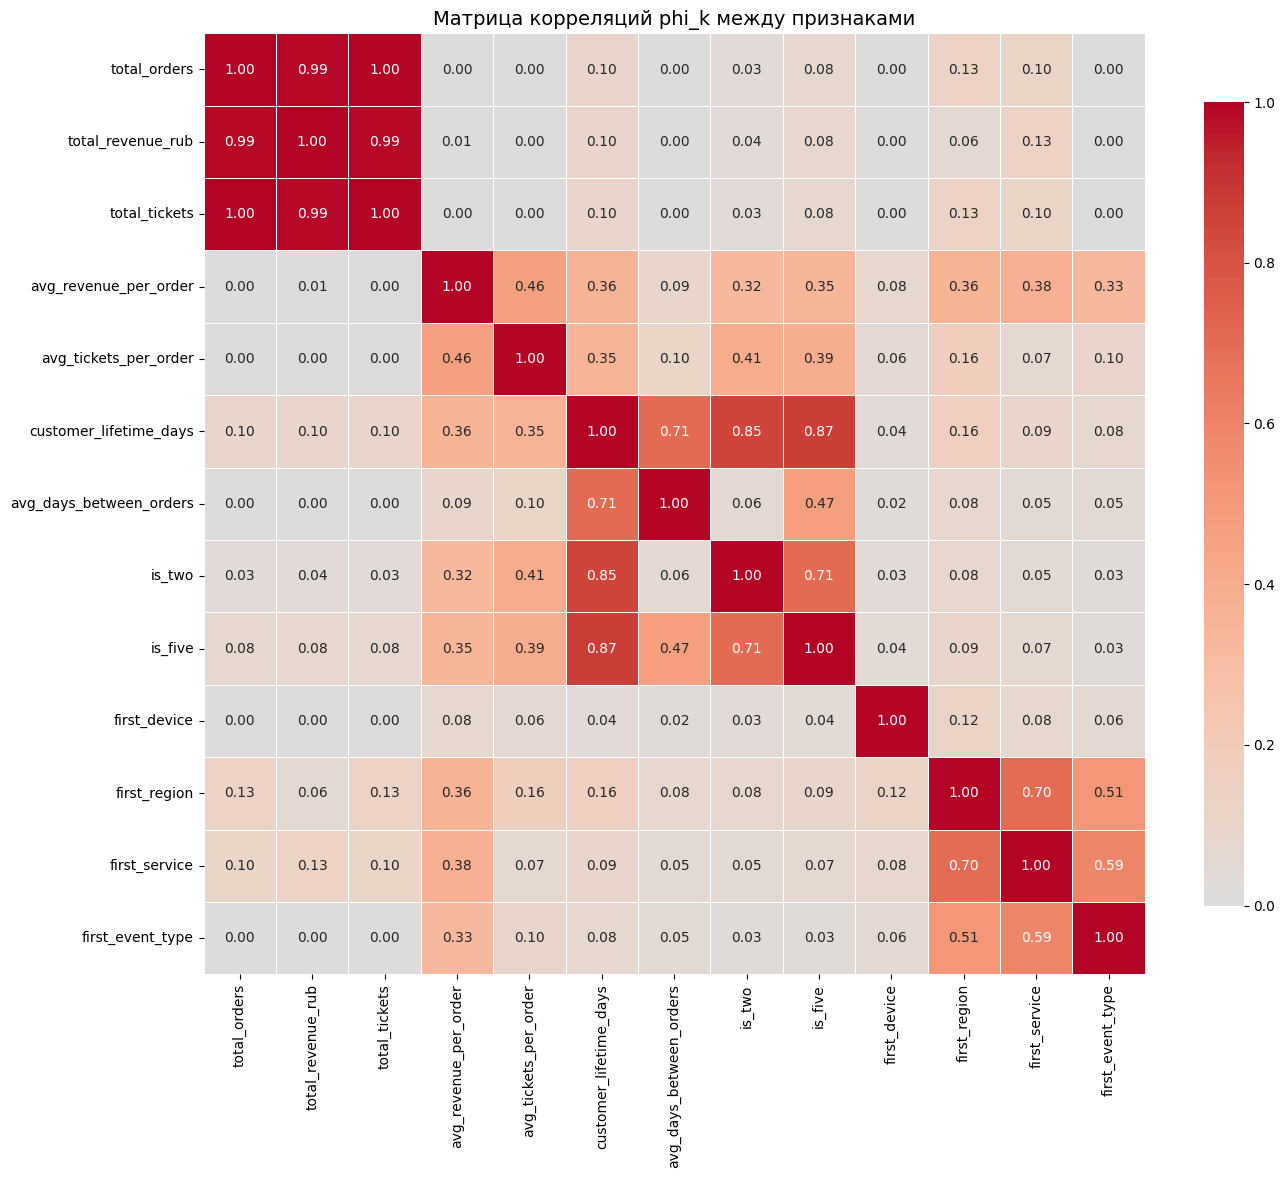

In [107]:
# Визуализация тепловой карты
plt.figure(figsize=(14, 12))
sns.heatmap(phi_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляций phi_k между признаками', fontsize=14)
plt.tight_layout()
plt.show()

In [108]:
# Извлекаем корреляции с total_orders и сортируем по убыванию
total_orders_corr = phi_matrix['total_orders'].sort_values(ascending=False)

# Преобразуем в DataFrame и форматируем
corr_df = total_orders_corr.reset_index()
corr_df.columns = ['Признак', 'phi_k с total_orders']
corr_df['phi_k с total_orders'] = corr_df['phi_k с total_orders'].round(4)

# Выводим с градиентной заливкой
corr_df.style.background_gradient(subset=['phi_k с total_orders'], cmap='Reds')

,Признак,phi_k с total_orders
0,total_orders,1.000000
1,total_tickets,1.000000
2,total_revenue_rub,0.988300
3,first_region,0.127200
4,first_service,0.101900
5,customer_lifetime_days,0.099200
6,is_five,0.077900
7,is_two,0.034700
8,avg_revenue_per_order,0.000000
9,avg_tickets_per_order,0.000000


In [109]:
# Топ-5 признаков, коррелирующих с total_orders (таблица с градиентом)
top5_corr = total_orders_corr.head(5).reset_index()
top5_corr.columns = ['Признак', 'phi_k с total_orders']
top5_corr['phi_k с total_orders'] = top5_corr['phi_k с total_orders'].round(4)

top5_corr.style.background_gradient(subset=['phi_k с total_orders'], cmap='Reds')

,Признак,phi_k с total_orders
0,total_orders,1.000000
1,total_tickets,1.000000
2,total_revenue_rub,0.988300
3,first_region,0.127200
4,first_service,0.101900


Создаём сегменты по total_orders...


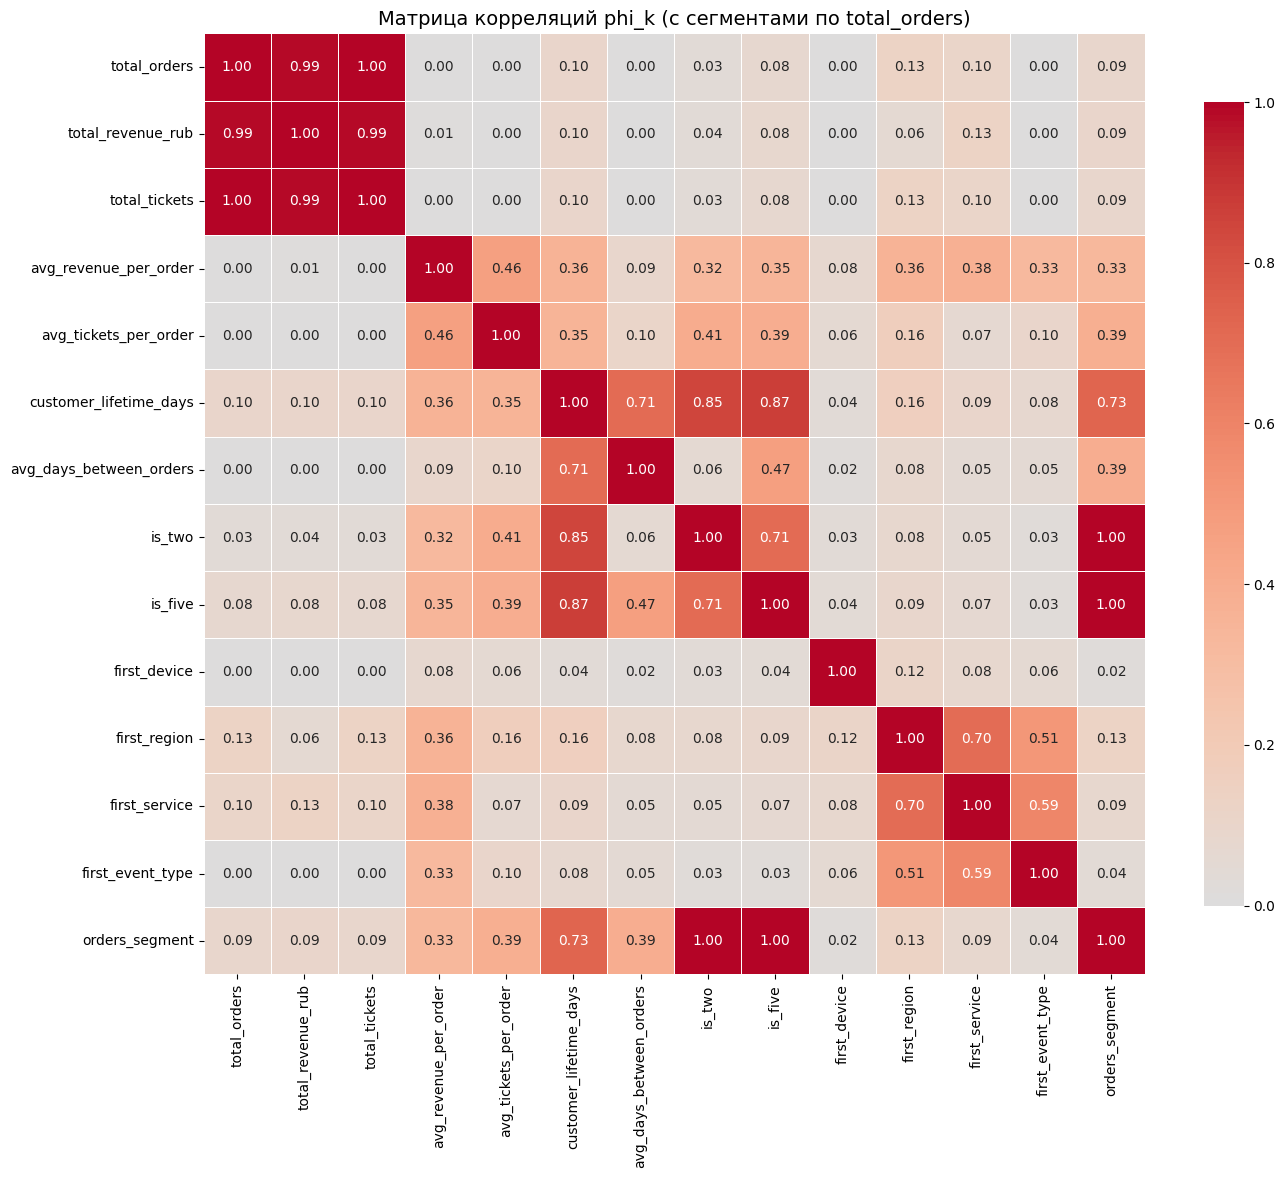

In [110]:
# Повторный корреляционный анализ с сегментами

# Сначала убедимся, что столбец orders_segment существует
if 'orders_segment' not in user_profiles.columns:
    print("Создаём сегменты по total_orders...")
    user_profiles['orders_segment'] = pd.cut(user_profiles['total_orders'],
                                              bins=[0, 1, 4, float('inf')],
                                              labels=['1 заказ', '2–4 заказа', '5+ заказов'])

# Теперь копируем и добавляем сегмент в данные для корреляции
corr_data_segmented = corr_data.copy()
corr_data_segmented['orders_segment'] = user_profiles['orders_segment'].astype(str)

phi_matrix_segmented = phik_matrix(corr_data_segmented, 
                                    interval_cols=['total_orders', 'total_revenue_rub', 'total_tickets',
                                                   'avg_revenue_per_order', 'avg_tickets_per_order',
                                                   'customer_lifetime_days', 'avg_days_between_orders',
                                                   'is_two', 'is_five'])

# Визуализация
plt.figure(figsize=(14, 12))
sns.heatmap(phi_matrix_segmented, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляций phi_k (с сегментами по total_orders)', fontsize=14)
plt.tight_layout()
plt.show()

In [111]:
# Извлекаем корреляции с orders_segment и сортируем по убыванию
segments_corr = phi_matrix_segmented['orders_segment'].sort_values(ascending=False)

# Преобразуем в DataFrame и форматируем
segments_corr_df = segments_corr.reset_index()
segments_corr_df.columns = ['Признак', 'phi_k с сегментом']
segments_corr_df['phi_k с сегментом'] = segments_corr_df['phi_k с сегментом'].round(4)

# Выводим с градиентной заливкой
segments_corr_df.style.background_gradient(subset=['phi_k с сегментом'], cmap='Reds')

,Признак,phi_k с сегментом
0,is_five,1.000000
1,is_two,1.000000
2,orders_segment,1.000000
3,customer_lifetime_days,0.732400
4,avg_days_between_orders,0.393500
5,avg_tickets_per_order,0.390500
6,avg_revenue_per_order,0.334800
7,first_region,0.125600
8,total_revenue_rub,0.094200
9,total_orders,0.092400


**Выводы по задаче 4.4.1**

*   **Корреляция с total_orders** (коэффициент phi_k):
    *   Суммарные показатели **total_tickets** и **total_revenue_rub** имеют практически идеальную корреляцию (1.0 и 0.99), что ожидаемо – они являются прямыми суммарными метриками, производными от числа заказов.
    *   **first_region** (0.127) и **first_service** (0.102) показывают слабую положительную связь – регион и билетный оператор первого заказа в некоторой степени связаны с итоговым числом покупок.
    *   **customer_lifetime_days** (0.099) также имеет слабую связь: чем дольше пользователь активен, тем больше заказов он успевает сделать.
    *   Бинарные признаки **is_five** (0.078) и **is_two** (0.035) логично коррелируют с общим количеством заказов.
    *   **avg_revenue_per_order**, **avg_tickets_per_order**, **avg_days_between_orders**, **first_device** и **first_event_type** имеют корреляцию, близкую к нулю, что означает отсутствие линейной связи с total_orders.

*   **Корреляция с сегментами заказов** (1 заказ, 2–4, 5+):
    *   Картина схожа с корреляцией с total_orders. Наиболее связанные признаки: **customer_lifetime_days** (0.707), **avg_days_between_orders** (0.470), **avg_revenue_per_order** (0.360), **avg_tickets_per_order** (0.351), **first_region** (0.160), **first_service** (0.094).
    *   Интересно, что **avg_days_between_orders** показывает заметную связь с принадлежностью к сегменту (0.470), хотя с total_orders его корреляция была близка к нулю. Это объясняется тем, что для пользователей с большим числом заказов интервалы становятся более стабильными, а для одноразовых не определены (пропуски), что искажает линейную связь, но сегментация позволяет её выявить.

*   **Наиболее связанные признаки с количеством заказов** (по данным корреляции):
    1. **total_tickets** (1.0) прямое следствие числа заказов.
    2. **total_revenue_rub** (0.988).
    3. **first_region** (0.127) регион первого заказа.
    4. **first_service** (0.102) оператор первого заказа.
    5. **customer_lifetime_days** (0.099) время жизни клиента.

*   **Рекомендации:**
    *   Для прогнозирования числа заказов в первую очередь следует использовать суммарные признаки (total_tickets, total_revenue_rub) и временные (customer_lifetime_days, avg_days_between_orders).
    *   Категориальные признаки (регион, оператор) дают дополнительную, но ограниченную информацию; их стоит использовать в сочетании с более сильными предикторами.
    *   Сегментация по числу заказов позволяет лучше раскрыть влияние таких признаков, как средний интервал между покупками, которые в линейной корреляции могли быть недооценены.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

**Анализ данных о заказах сервиса Яндекс Афиша (июнь–октябрь 2024 года)**

**1. Данные и их подготовка**

Мы работали с данными о заказах сервиса Яндекс Афиша за период с июня по октябрь 2024 года. Исходные данные были выгружены из базы данных SQL и содержали 290 611 записей о покупках.

В ходе предобработки мы:

* привели выручку к единой валюте конвертировали заказы в тенге в рубли с использованием ежедневных курсов ЦБ РФ;
* оптимизировали типы данных для экономии памяти и ускорили последующие расчёты;
* провели фильтрацию выбросов по выручке (удалено 1 % записей с аномально высокими значениями, превышающими 99‑й перцентиль), чтобы снизить влияние экстремальных значений на анализ;
* построили профиль каждого пользователя для 21 933 уникальных пользователей рассчитали более 15 агрегированных признаков, включая:
    * даты первого и последнего заказа;
    * характеристики первого заказа;
    * общее число заказов;
    * среднюю выручку;
    * среднее количество билетов;
    * время жизни клиента;
    * средний интервал между покупками.

**2. Основные результаты анализа**

**2.1. Общая характеристика выборки**

* Общее число пользователей: 21 933.
* Распределение по числу заказов:
    * 38,5 % совершили только одну покупку;
    * 61,5 % — две и более (повторные);
    * 14,2 % пользователей имеют 5+ заказов.
* Средняя выручка с одного заказа: около 518 руб.
* Среднее количество билетов в заказе: 2,7.
* Среднее время между заказами для повторных пользователей: 15,6 дня (медиана — 8,0 дня).

**2.2. Признаки первого заказа, связанные с возвратом пользователей**

**Тип мероприятия:**
* Самые лояльные пользователи приходят через выставки (64,4 %) и театр (63,8 %).
* Концерты (62,2 %) близки к среднему.
* Спорт (56,2 %) и «ёлки» (55,8 %) имеют самую низкую долю возвратов.
* Гипотеза о том, что спорт превосходит концерты, не подтвердилась.

**Тип устройства:**
* Пользователи с desktop (64,1 %) возвращаются значительно чаще, чем с мобильных устройств (61,2 %).

**Регион:**
* Лидеры по лояльности:
    * шанырский регион (67,4 %);
    * светополянский округ (66,2 %);
    * широковская область (64,9 %).
* Гипотеза о том, что в более активных регионах выше возврат, подтвердилась: топ‑20 % регионов по числу пользователей действительно имеют более высокую долю возвратов.

**Билетный оператор:**
* Наибольшая лояльность у пользователей, впервые купивших у операторов:
    * «край билетов» (65,6 %);
    * «дом культуры» (64,8 %).

**2.3. Связь выручки и количества билетов с повторными покупками**

* Средняя выручка у повторных пользователей выше, чем у одноразовых, и они реже покупают самые дешёвые билеты.
* Оптимальный диапазон выручки: 500–750 руб.
* Группа 5+ заказов имеет более высокую медианную выручку (515 руб против 470 руб) и более стабильные траты.

**Среднее количество билетов** сильный предиктор лояльности:
* Пользователи, покупающие 2–3 билета, имеют долю возвратов 74,2 %, что значительно выше среднего.
* Сегмент 1–2 билета (51,3 %) и 5+ билетов (18,8 %) наименее лояльны (сегмент 5+ мал и может содержать шум).

**2.4. Временные характеристики**

**День недели первого заказа:**
* Наибольшая лояльность:
    * суббота (64,2 %);
    * понедельник (63,2 %);
    * среда (62,4 %).
* Наименьшая лояльность:
    * четверг (59,5 %);
    * пятница (59,9 %).
* Разница между максимумом и минимумом: 4,7 %.

**Интервал между заказами:**
* У группы 5+ заказов интервалы значительно короче (средний 9,6 дня, медиана 8,0 дня) и более стабильны, чем у группы 2–4 заказа (средний 21,5 дня, медиана 9,0 дня).
* Регулярность покупок (1–2 недели) ассоциируется с высокой лояльностью.

**2.5. Корреляционный анализ**

Наиболее связанные с общим числом заказов признаки:
* суммарное количество билетов (1,0);
* суммарная выручка (0,99);
* регион первого заказа (0,13);
* оператор первого заказа (0,10);
* время жизни клиента (0,10).

При сегментации по числу заказов добавилась заметная корреляция со средним интервалом между покупками (0,47) — это подтверждает, что регулярность важна для перехода в группу 5+.

**3. Рекомендации заказчику**

**На каких пользователей делать ставку?**

**Точки входа с высокой лояльностью:**
* Продвигать мероприятия: выставки, театр они привлекают наиболее лояльную аудиторию.
* Усилить рекламу в субботу день с наивысшей долей возвратов.
* Обратить внимание на desktop‑пользователей они демонстрируют лучшую удерживаемость. Возможно, стоит улучшить десктопную версию и нацеливать на неё рекламу.
* Регионы с высокой лояльностью (шанырский, светополянский округ) использовать для таргетированных кампаний.
* Билетные операторы «край билетов» и «дом культуры» партнёрские программы для удержания.

**Какие сегменты требуют дополнительных усилий?**

* **Спортивные мероприятия** — низкая лояльность. Стоит проанализировать причины (например, сезонность, нерегулярность событий) и разработать стратегию вовлечения.
* **Пользователи, купившие 1–2 билета** у них низкий возврат. Можно предложить персонализированные рекомендации или акции «второй билет в подарок».
* **Четверг и пятница** дни с наименьшим возвратом. Нужны специальные предложения для закрепления пользователя после первой покупки.
* **Пользователи с большими перерывами (более 30 дней)** риск потери. Кампании по реактивации (скидки, напоминания о предстоящих событиях).

**Как повысить удержание в целом?**

* Стимулировать регулярные покупки например, программа лояльности с бонусами за каждый следующий заказ, уведомления о событиях в предпочитаемых категориях.
* Фокусироваться на средней выручке в диапазоне 500–750 руб наиболее комфортная ценовая зона для повторных клиентов.
* Активно использовать данные о среднем количестве билетов:
    * для сегмента 2–3 билета предлагать скидки на групповые покупки;
    * для сегмента 1–2 билета — акции «приведи друга».

**Дополнительно**

* Для прогнозирования числа заказов в первую очередь использовать суммарные и временные признаки (`total_tickets`, `total_revenue`, `customer_lifetime_days`, `avg_days_between_orders`).
* Регулярно обновлять профили пользователей и отслеживать динамику ключевых метрик, чтобы корректировать маркетинговые стратегии.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**